# Experiment 2: Flat Interpolation

**Purpose (Jan23.md):** Demonstrate that without distributional assumptions on the induced patch set, LCN-WS can interpolate while remaining stable (satisfying BEoS). This shows architecture alone is not sufficient for generalization.

**Setup:**
- **Disjoint receptive fields**: All patches are non-overlapping
- **Data generation**: Each patch sampled independently from $\mathbb{S}^{m-1}$
  - $x^{(j)} \sim \mathbb{S}^{m-1}$ for $j = 1, \ldots, J$
  - $x = \text{Concat}[x^{(1)}, \ldots, x^{(J)}]$
  - $y = f_{\text{true}}(x) + \xi$

**Key Difference from Experiment 1:**
- Exp 1: $x \sim \mathbb{S}^{d-1}$ (whole vector on ambient sphere)
- Exp 2: Each patch $x^{(j)} \sim \mathbb{S}^{m-1}$ independently (patch-wise sphere)

**Metrics:**
1. Train Loss: $\frac{1}{n}\sum(f_{\text{pred}} - y)^2$
2. Train MSE (clean): $\frac{1}{n}\sum(f_{\text{pred}} - f_{\text{true}})^2$
3. Loss curvature: $\lambda_{\max}(\nabla^2 \mathcal{L}(\theta))$
4. Filter activation: $\text{ActRatio}_k = \frac{\#\text{patches activated by filter } k}{n \cdot J}$
5. Path norm: $|v_k| \cdot \|w_k\|$

**Plots:**
1. Training curves
2. Scatter: Path-norm vs ActRatio for each filter

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from scipy import stats
from tqdm import tqdm
import os

# Ensure determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

from synthetic_teacher_experiments import (
    generate_views, create_ground_truth_function, SyntheticModel, ViewStrategy
)
from src.networks import FullyConnectedBaseline

# Try to import PyHessian for Hessian computation
try:
    from pyhessian import hessian
    PYHESSIAN_AVAILABLE = True
    print("PyHessian available for Hessian computation.")
except ImportError:
    PYHESSIAN_AVAILABLE = False
    print("PyHessian not available. Will use power iteration for Hessian.")

# =============================================================================
# OUTPUT DIRECTORY
# =============================================================================
SAVE_DIR = 'plots'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Plots will be saved to: {SAVE_DIR}/")

# =============================================================================
# GLOBAL PLOTTING CONFIG (ICML Conference Format)
# =============================================================================
PLOT_CONFIG = {
    'title_fontsize': 18,
    'label_fontsize': 18,
    'tick_fontsize': 14,
    'legend_fontsize': 16,
    'linewidth': 2.5,
    'markersize': 12,
    'single_fig_size': (6, 5),
    'double_fig_size': (12, 5),
    'grid_alpha': 0.3,
    'dpi': 300,
}

plt.rcParams.update({
    'font.size': PLOT_CONFIG['tick_fontsize'],
    'axes.titlesize': PLOT_CONFIG['title_fontsize'],
    'axes.labelsize': PLOT_CONFIG['label_fontsize'],
    'xtick.labelsize': PLOT_CONFIG['tick_fontsize'],
    'ytick.labelsize': PLOT_CONFIG['tick_fontsize'],
    'legend.fontsize': PLOT_CONFIG['legend_fontsize'],
    'figure.dpi': PLOT_CONFIG['dpi'],
    'lines.linewidth': PLOT_CONFIG['linewidth'],
    'lines.markersize': PLOT_CONFIG['markersize'],
    # Type-1/TrueType fonts for publication (required by IEEE, ACM, NeurIPS, ICML, etc.)
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# Pretty colors and markers
PRETTY_COLORS = {'FCN': '#E74C3C', 'LCN-WS': '#3498DB'}
MARKERS = {'FCN': 's', 'LCN-WS': 'o'}

# Colors for different d values
D_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6', '#F39C12', '#1ABC9C']
D_COLORS_DARK = ['#C0392B', '#2874A6', '#1E8449', '#6C3483', '#B9770E', '#E91E63']
D_MARKERS = ['o', 's', '^', 'D', 'v', 'p']
D_LINESTYLES = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))]

ARCH_DISPLAY_NAMES = {'fully_connected': 'FCN', 'shared_cnn': 'LCN-WS'}

# =============================================================================
# GLOBAL TICK FORMATTER
# =============================================================================
def decimal_tick_formatter(x, pos):
    """Format tick labels as decimals."""
    if x == 0:
        return '0'
    elif abs(x) >= 1:
        return f'{x:.1f}'
    elif abs(x) >= 0.1:
        return f'{x:.2f}'
    elif abs(x) >= 0.01:
        return f'{x:.3f}'
    else:
        return f'{x:.4f}'

print("Config loaded (with Type-1/TrueType fonts for publication).")

In [2]:
# =============================================================================
# MEMORY CLEANUP - Run this if you get CUDA out of memory errors
# =============================================================================
import gc

# Clear PyTorch CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    
gc.collect()

# Show current GPU memory usage
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory allocated: {torch.cuda.memory_allocated(0) / 1024**2:.1f} MiB")
    print(f"Memory reserved:  {torch.cuda.memory_reserved(0) / 1024**2:.1f} MiB")
else:
    print("CUDA not available, using CPU")

GPU: NVIDIA A10G
Memory allocated: 0.0 MiB
Memory reserved:  0.0 MiB


## Config

In [3]:
# =============================================================================
# DATA CONFIG (Experiment 2: Flat Interpolation)
# =============================================================================
DATA_CONFIG = {
    'm': 10,            # patch size
    'J': 8,           # number of disjoint patches (d = J * m)
    'K_true': 50,      # ground truth width
    'K_model': 1024,   # model width for LCN-WS (over-parameterized) - matching reference
    'N_train': 512,    # training samples
    'sigma': 1.0,      # noise std
    'seed': 42,
}
DATA_CONFIG['d'] = DATA_CONFIG['J'] * DATA_CONFIG['m']  # ambient dimension

# =============================================================================
# PARAMETER MATCHING: Compute K for FCN to match LCN-WS params
# =============================================================================
lcnws_params = DATA_CONFIG['K_model'] * (DATA_CONFIG['m'] + 3) + 1
fcn_K = (lcnws_params - 1) // (DATA_CONFIG['d'] + 2)
fcn_params = fcn_K * (DATA_CONFIG['d'] + 2) + 1

print(f"Parameter Matching:")
print(f"  LCN-WS: K={DATA_CONFIG['K_model']}, params={lcnws_params}")
print(f"  FCN:    K={fcn_K}, params={fcn_params}")
print(f"  Difference: {abs(lcnws_params - fcn_params)} params")

DATA_CONFIG['K_fcn'] = fcn_K

# =============================================================================
# TRAINING CONFIG - Larger learning rate to see neuron specialization
# =============================================================================
TRAIN_CONFIG = {
    'optimizer': 'sgd',
    'lr': 0.2,             # Large learning rate like reference plot
    'weight_decay': 0.0,   # No regularization (like top reference plot)
    'momentum': 0.0,
    'grad_clip': 100,       # Gradient clipping for stability
    'epochs': 50000,
}

# =============================================================================
# MODEL CONFIG
# =============================================================================
# NOTE: SyntheticModel now uses proper initialization by default:
#   - Weights: Kaiming He (std = sqrt(2/fan_in))
#   - Biases: zeros
# The bias_init option is now redundant (model already defaults to 0),
# but kept for backwards compatibility and explicit documentation.
MODEL_CONFIG = {
    'bias_init': None,     # None = use model default (zeros). Set to override.
}

# =============================================================================
# HESSIAN CONFIG
# =============================================================================
HESSIAN_CONFIG = {
    'compute_hessian': True,
    'hessian_frequency': 50,
    'hessian_method': 'pyhessian',
    'power_iter_steps': 20,
}

# =============================================================================
# FILTER ANALYSIS CONFIG
# =============================================================================
FILTER_CONFIG = {
    'compute_activation': True,
    'compute_pathnorm': True,
    'analysis_frequency': 50,
}

# =============================================================================
# PRINT SUMMARY
# =============================================================================
print("\n" + "="*60)
print("EXPERIMENT 2: Flat Interpolation")
print("="*60)
print(f"\nDATA (patch-wise sphere sampling):")
print(f"  m={DATA_CONFIG['m']}, J={DATA_CONFIG['J']}, d={DATA_CONFIG['d']}")
print(f"  K_true={DATA_CONFIG['K_true']}, K_model={DATA_CONFIG['K_model']}")
print(f"  N_train={DATA_CONFIG['N_train']}, sigma={DATA_CONFIG['sigma']}")

print(f"\nTRAINING:")
print(f"  lr={TRAIN_CONFIG['lr']}, weight_decay={TRAIN_CONFIG['weight_decay']}")
print(f"  grad_clip={TRAIN_CONFIG['grad_clip']}")
print(f"  Edge of stability (2/η): {2.0/TRAIN_CONFIG['lr']:.1f}")
print(f"  epochs={TRAIN_CONFIG['epochs']}")

print(f"\nMODEL INIT:")
print(f"  Weights: Kaiming He (mode='fan_in', nonlinearity='relu')")
print(f"  Biases: {MODEL_CONFIG['bias_init'] if MODEL_CONFIG['bias_init'] is not None else 'zeros (default)'}")
print("="*60)

Parameter Matching:
  LCN-WS: K=1024, params=13313
  FCN:    K=162, params=13285
  Difference: 28 params

EXPERIMENT 2: Flat Interpolation

DATA (patch-wise sphere sampling):
  m=10, J=8, d=80
  K_true=50, K_model=1024
  N_train=512, sigma=1.0

TRAINING:
  lr=0.2, weight_decay=0.0
  grad_clip=100
  Edge of stability (2/η): 10.0
  epochs=50000

MODEL INIT:
  Weights: Kaiming He (mode='fan_in', nonlinearity='relu')
  Biases: zeros (default)


## 1. Data Generation (Patch-wise Sphere Sampling)

**Key**: Each patch $x^{(j)} \sim \mathbb{S}^{m-1}$ is sampled independently, then concatenated.

In [4]:
# create_ground_truth_function is already imported from synthetic_teacher_experiments

def generate_patchwise_sphere_data(m, J, K_true, N, sigma, seed, H=None, gt_fn=None):
    """
    Generate data where each patch is sampled independently from S^{m-1}.
    
    This is the KEY difference from Experiment 1:
    - Exp 1: x ~ S^{d-1} (whole vector on ambient sphere)
    - Exp 2: x^(j) ~ S^{m-1} independently, then x = Concat[x^(1), ..., x^(J)]
    
    Args:
        m: Patch size
        J: Number of patches
        K_true: Ground truth network width
        N: Number of samples
        sigma: Noise level
        seed: Random seed
        H: View indices (if None, generate disjoint blocks)
        gt_fn: Ground truth function (if None, create new one)
    
    Returns:
        X, y_clean, y_noisy, H, gt_fn
    """
    d = J * m
    rng = np.random.default_rng(seed)
    
    # Generate disjoint views if not provided
    if H is None:
        H = np.array([np.arange(j * m, (j + 1) * m) for j in range(J)])
    
    # Create ground truth function if not provided
    if gt_fn is None:
        gt_fn = create_ground_truth_function(d, K_true, H, seed)
    
    # Generate X: each patch independently on S^{m-1}
    X = np.zeros((N, d))
    for i in range(N):
        for j in range(J):
            # Sample patch from S^{m-1}
            patch = rng.normal(0, 1, m)
            patch = patch / np.linalg.norm(patch)  # Normalize to unit sphere
            X[i, j * m:(j + 1) * m] = patch
    
    X = torch.from_numpy(X).float()
    
    # Generate clean labels
    with torch.no_grad():
        y_clean = gt_fn(X)
    
    # Add noise
    noise = torch.from_numpy(rng.normal(0, sigma, N)).float()
    y_noisy = y_clean + noise
    
    return X, y_clean, y_noisy, H, gt_fn

# Generate data
print("Generating patch-wise sphere data...")
X_train, y_clean_train, y_noisy_train, H, gt_fn = generate_patchwise_sphere_data(
    DATA_CONFIG['m'], DATA_CONFIG['J'], DATA_CONFIG['K_true'],
    DATA_CONFIG['N_train'], DATA_CONFIG['sigma'], DATA_CONFIG['seed']
)

print(f"X_train shape: {X_train.shape}")
print(f"H (views) shape: {H.shape}")
print(f"y_clean: mean={y_clean_train.mean():.3f}, std={y_clean_train.std():.3f}")
print(f"y_noisy: mean={y_noisy_train.mean():.3f}, std={y_noisy_train.std():.3f}")

# Verify patch norms (should all be 1)
patch_norms = []
for j in range(DATA_CONFIG['J']):
    patch = X_train[:, j * DATA_CONFIG['m']:(j + 1) * DATA_CONFIG['m']]
    norms = torch.norm(patch, dim=1)
    patch_norms.append(norms.mean().item())
print(f"Average patch norms: {np.mean(patch_norms):.4f} (should be 1.0)")

Generating patch-wise sphere data...
X_train shape: torch.Size([512, 80])
H (views) shape: (8, 10)
y_clean: mean=1.171, std=0.986
y_noisy: mean=1.140, std=1.423
Average patch norms: 1.0000 (should be 1.0)


## 2. Model Creation

In [5]:
def create_model(arch, d, m, K, H, seed=0, bias_init=None):
    """Create model with optional bias initialization override.

    Args:
        arch: Architecture type ('fully_connected' or 'shared_cnn')
        d: Ambient dimension
        m: Patch size
        K: Number of filters
        H: View indices
        seed: Random seed
        bias_init: Override for bias initialization.
            - None (default): Use model's default (zeros with Kaiming He weights)
            - float: Fill all biases with this value

    Returns:
        Model instance
    
    Note: SyntheticModel from synthetic_teacher_experiments uses:
        - model.W (Linear layer for filter weights)
        - model.b (bias parameter)
        - model.v (readout weights)
        - model.beta (readout bias)
    """
    torch.manual_seed(seed)
    if arch == 'fully_connected':
        return FullyConnectedBaseline(d, K)
    elif arch == 'shared_cnn':
        model = SyntheticModel(d, K, H)
        # Only override biases if explicitly requested
        if bias_init is not None:
            with torch.no_grad():
                model.b.fill_(bias_init)
        return model

# =============================================================================
# Show both architectures with MATCHED parameters
# =============================================================================
print("Architecture Comparison (Parameter Matched):")
print("-" * 60)

# LCN-WS
model_lcnws = create_model('shared_cnn', DATA_CONFIG['d'], DATA_CONFIG['m'], 
                           DATA_CONFIG['K_model'], H, DATA_CONFIG['seed'],
                           bias_init=MODEL_CONFIG['bias_init'])
params_lcnws = sum(p.numel() for p in model_lcnws.parameters())

# FCN with matched K
model_fcn = create_model('fully_connected', DATA_CONFIG['d'], DATA_CONFIG['m'],
                         DATA_CONFIG['K_fcn'], H, DATA_CONFIG['seed'])
params_fcn = sum(p.numel() for p in model_fcn.parameters())

print(f"LCN-WS: K={DATA_CONFIG['K_model']:>5}, params={params_lcnws:>7,}")
print(f"FCN:    K={DATA_CONFIG['K_fcn']:>5}, params={params_fcn:>7,}")
print("-" * 60)

# Use LCN-WS for this experiment
model = model_lcnws

# =============================================================================
# DEBUG: Check model initialization
# =============================================================================
def debug_model(model, X, y_target, H):
    """Debug model initialization.
    
    Note: Uses model.W and model.b (SyntheticModel from synthetic_teacher_experiments)
    """
    model.eval()
    X_dev = X.to(DEVICE)
    model_dev = model.to(DEVICE)
    
    with torch.no_grad():
        pred = model_dev(X_dev)
        
        print("\n" + "=" * 60)
        print("DEBUG: Model Initialization")
        print("=" * 60)
        print(f"Target y: mean={y_target.mean():.3f}, std={y_target.std():.3f}")
        print(f"Model pred: mean={pred.mean():.3f}, std={pred.std():.3f}")
        print(f"Initial MSE: {((pred.cpu() - y_target) ** 2).mean().item():.3f}")
        
        # Check ReLU activations (only for LCN-WS / SyntheticModel)
        if hasattr(model_dev, 'W'):
            N = X_dev.shape[0]
            L, m = H.shape
            
            H_tensor = model_dev.H.to(X_dev.device)
            X_patches = X_dev[:, H_tensor]
            X_flat = X_patches.reshape(N * L, m)
            
            pre_act = model_dev.W(X_flat) - model_dev.b
            active = (pre_act > 0).float()
            
            print(f"\nReLU activations: {100*active.mean().item():.1f}%")
            print(f"Filters with >0 act: {(active.mean(dim=0) > 0).sum().item()} / {model_dev.K}")
            
            # Show weight initialization stats
            W = model_dev.W.weight
            print(f"\nWeight init: mean={W.mean().item():.4f}, std={W.std().item():.4f}")
            print(f"Bias init: mean={model_dev.b.mean().item():.4f}, std={model_dev.b.std().item():.4f}")
        print("=" * 60)

debug_model(model, X_train, y_noisy_train, H)

Architecture Comparison (Parameter Matched):
------------------------------------------------------------
LCN-WS: K= 1024, params= 12,289
FCN:    K=  162, params= 13,285
------------------------------------------------------------

DEBUG: Model Initialization
Target y: mean=1.140, std=1.423
Model pred: mean=0.057, std=0.097
Initial MSE: 3.197

ReLU activations: 50.0%
Filters with >0 act: 1024 / 1024

Weight init: mean=0.0063, std=0.4489
Bias init: mean=0.0000, std=0.0000


## 3. Metric Computation Functions

In [6]:
def compute_hessian_max_eigenvalue_power_iter(model, X, y, criterion, num_steps=20):
    """
    Compute largest eigenvalue of Hessian using power iteration.
    """
    model.eval()
    params = [p for p in model.parameters() if p.requires_grad]
    
    # Initialize random vector
    v = [torch.randn_like(p) for p in params]
    v_norm = sum((vi ** 2).sum() for vi in v).sqrt()
    v = [vi / v_norm for vi in v]
    
    for _ in range(num_steps):
        model.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        grads = torch.autograd.grad(loss, params, create_graph=True)
        gv = sum((g * vi).sum() for g, vi in zip(grads, v))
        Hv = torch.autograd.grad(gv, params, retain_graph=True)
        v = [hvi.detach() for hvi in Hv]
        v_norm = sum((vi ** 2).sum() for vi in v).sqrt()
        v = [vi / v_norm for vi in v]
    
    # Compute Rayleigh quotient
    model.zero_grad()
    pred = model(X)
    loss = criterion(pred, y)
    grads = torch.autograd.grad(loss, params, create_graph=True)
    gv = sum((g * vi).sum() for g, vi in zip(grads, v))
    Hv = torch.autograd.grad(gv, params)
    eigenvalue = sum((hvi * vi).sum() for hvi, vi in zip(Hv, v)).item()
    
    return eigenvalue


def compute_hessian_max_eigenvalue_pyhessian(model, X, y, criterion):
    """Compute largest eigenvalue using PyHessian."""
    if not PYHESSIAN_AVAILABLE:
        return None
    # PyHessian expects data=(inputs, targets), not a list
    hessian_comp = hessian(model, criterion, data=(X, y), cuda=(X.device.type == 'cuda'))
    top_eigenvalues, _ = hessian_comp.eigenvalues(top_n=1)
    return top_eigenvalues[0]


def compute_filter_activation_ratio(model, X, H):
    """
    Compute activation ratio for each filter.
    ActRatio_k = (# patches with ReLU active) / (n * J)
    
    Note: Uses model.W and model.b (SyntheticModel from synthetic_teacher_experiments)
    """
    model.eval()
    N = X.shape[0]
    J = H.shape[0]
    K = model.K
    
    with torch.no_grad():
        H_tensor = model.H.to(X.device)
        X_patches = X[:, H_tensor]  # (N, J, m)
        X_flat = X_patches.reshape(N * J, -1)
        
        # Pre-activation: W(x) - b
        pre_act = model.W(X_flat) - model.b
        
        activated = (pre_act > 0).float()
        act_counts = activated.sum(dim=0)
        act_ratios = act_counts / (N * J)
    
    return act_ratios.cpu().numpy()


def compute_weight_norms(model):
    """
    Compute weight norm for each filter: ||w_k||
    (This is what the reference plot uses)
    
    Note: Uses model.W (SyntheticModel from synthetic_teacher_experiments)
    """
    with torch.no_grad():
        W = model.W.weight  # (K, m)
        w_norms = torch.norm(W, dim=1)   # (K,)
    return w_norms.cpu().numpy()


def compute_path_norms(model):
    """
    Compute path norm for each filter: PathNorm_k = |v_k| * ||w_k||
    
    Note: Uses model.W and model.v (SyntheticModel from synthetic_teacher_experiments)
    """
    with torch.no_grad():
        W = model.W.weight  # (K, m)
        v = model.v  # (K,)
        
        w_norms = torch.norm(W, dim=1)  # (K,)
        v_abs = torch.abs(v)
        path_norms = v_abs * w_norms
    
    return path_norms.cpu().numpy()


print("Metric computation functions defined.")

Metric computation functions defined.


## 4. Training with Metric Tracking

In [7]:
def train_with_metrics(model, X, y_noisy, y_clean, H, train_config, hessian_config, filter_config, log_every=100):
    """
    Train model and track all metrics from Experiment 2.
    
    Returns:
        history dict with all metrics
    """
    model = model.to(DEVICE)
    X = X.to(DEVICE)
    y_noisy = y_noisy.to(DEVICE)
    y_clean = y_clean.to(DEVICE)
    
    # Optimizer
    if train_config['optimizer'] == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=train_config['lr'], 
                               weight_decay=train_config['weight_decay'])
    else:
        opt = torch.optim.SGD(model.parameters(), lr=train_config['lr'],
                              momentum=train_config['momentum'],
                              weight_decay=train_config['weight_decay'])
    
    criterion = nn.MSELoss()
    epochs = train_config['epochs']
    grad_clip = train_config['grad_clip']
    
    # History
    history = {
        'train_loss': [],
        'train_mse_clean': [],
        'grad_norm': [],
        'hessian_max_eigenvalue': [],
        'hessian_epochs': [],
        'filter_analysis_epochs': [],
        'activation_ratios': [],  # List of arrays (K,)
        'path_norms': [],          # List of arrays (K,)
        'weight_norms': [],        # List of arrays (K,) - for reference-style plots
    }
    
    for ep in tqdm(range(epochs), desc="Training"):
        # Forward pass
        model.train()
        opt.zero_grad()
        pred = model(X)
        loss = criterion(pred, y_noisy)
        loss.backward()
        
        # Gradient norm
        gn = sum(p.grad.norm().item()**2 for p in model.parameters() if p.grad is not None)**0.5
        
        # Gradient clipping
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        
        opt.step()
        
        # Evaluate
        model.eval()
        with torch.no_grad():
            pred = model(X)
            train_loss = criterion(pred, y_noisy).item()
            train_mse_clean = criterion(pred, y_clean).item()
        
        history['train_loss'].append(train_loss)
        history['train_mse_clean'].append(train_mse_clean)
        history['grad_norm'].append(gn)
        
        # Hessian computation (at specified frequency)
        if hessian_config['compute_hessian'] and (ep % hessian_config['hessian_frequency'] == 0 or ep == epochs - 1):
            if hessian_config['hessian_method'] == 'pyhessian' and PYHESSIAN_AVAILABLE:
                lambda_max = compute_hessian_max_eigenvalue_pyhessian(model, X, y_noisy, criterion)
            else:
                lambda_max = compute_hessian_max_eigenvalue_power_iter(
                    model, X, y_noisy, criterion, hessian_config['power_iter_steps']
                )
            history['hessian_max_eigenvalue'].append(lambda_max)
            history['hessian_epochs'].append(ep)
        
        # Filter analysis (at specified frequency)
        if (filter_config['compute_activation'] or filter_config['compute_pathnorm']) and \
           (ep % filter_config['analysis_frequency'] == 0 or ep == epochs - 1):
            history['filter_analysis_epochs'].append(ep)
            
            if filter_config['compute_activation']:
                act_ratios = compute_filter_activation_ratio(model, X, H)
                history['activation_ratios'].append(act_ratios)
            
            if filter_config['compute_pathnorm']:
                path_norms = compute_path_norms(model)
                history['path_norms'].append(path_norms)
                weight_norms = compute_weight_norms(model)
                history['weight_norms'].append(weight_norms)
        
        # Logging
        if ep % log_every == 0 or ep == epochs - 1:
            msg = f"Ep {ep:5d}: loss={train_loss:.4f}, mse_clean={train_mse_clean:.4f}, grad={gn:.2e}"
            if len(history['hessian_max_eigenvalue']) > 0 and ep in history['hessian_epochs']:
                msg += f", lambda_max={history['hessian_max_eigenvalue'][-1]:.2e}"
            tqdm.write(msg)
    
    return history

print("Training function defined.")

Training function defined.


## 5. Run Experiment

In [8]:
# Create model
model = create_model('shared_cnn', DATA_CONFIG['d'], DATA_CONFIG['m'],
                     DATA_CONFIG['K_model'], H, DATA_CONFIG['seed'],
                     bias_init=MODEL_CONFIG['bias_init'])

print(f"Training LCN-WS on patch-wise sphere data...")
print(f"Data: N={DATA_CONFIG['N_train']}, d={DATA_CONFIG['d']}, J={DATA_CONFIG['J']}, m={DATA_CONFIG['m']}")
print(f"Model: K={DATA_CONFIG['K_model']}, bias_init={MODEL_CONFIG['bias_init']}")
print()

# =============================================================================
# CAPTURE INITIAL STATE (before training)
# =============================================================================
model_temp = model.to(DEVICE)
X_temp = X_train.to(DEVICE)

initial_weight_norms = compute_weight_norms(model_temp)
initial_act_ratios = compute_filter_activation_ratio(model_temp, X_temp, H)
initial_path_norms = compute_path_norms(model_temp)

print(f"Initial state captured:")
print(f"  Weight Norms: mean={initial_weight_norms.mean():.4f}, std={initial_weight_norms.std():.4f}")
print(f"  Act Ratios:   mean={initial_act_ratios.mean():.4f}, std={initial_act_ratios.std():.4f}")
print()

# Train
history = train_with_metrics(
    model, X_train, y_noisy_train, y_clean_train, H,
    TRAIN_CONFIG, HESSIAN_CONFIG, FILTER_CONFIG,
    log_every=500
)

# Store initial state in history for plotting
history['initial_weight_norms'] = initial_weight_norms
history['initial_act_ratios'] = initial_act_ratios
history['initial_path_norms'] = initial_path_norms

print(f"\nFinal: loss={history['train_loss'][-1]:.4f}, mse_clean={history['train_mse_clean'][-1]:.4f}")

Training LCN-WS on patch-wise sphere data...
Data: N=512, d=80, J=8, m=10
Model: K=1024, bias_init=None

Initial state captured:
  Weight Norms: mean=1.3845, std=0.3140
  Act Ratios:   mean=0.5001, std=0.0067



Training:   0%|          | 0/50000 [00:00<?, ?it/s]/home/anirudh_agarwal/.airconda-environments/production--ml_infra--redspot--default--v0.4.39/lib/python3.12/site-packages/torch/autograd/graph.py:841: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at /pytorch/torch/csrc/autograd/engine.cpp:1291.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Training:   0%|          | 55/50000 [00:00<02:59, 277.85it/s]

Ep     0: loss=209.5536, mse_clean=207.6121, grad=1.30e+01, lambda_max=8.35e+01


Training:   1%|          | 592/50000 [00:01<01:33, 526.29it/s]

Ep   500: loss=0.7266, mse_clean=0.1910, grad=6.23e-02, lambda_max=8.83e+00


...

Ep 49000: loss=0.0000, mse_clean=1.0417, grad=1.28e-03, lambda_max=9.99e+00


Training:  99%|█████████▉| 49585/50000 [01:34<00:00, 528.15it/s]

Ep 49500: loss=0.0000, mse_clean=1.0417, grad=1.19e-03, lambda_max=9.99e+00


Training: 100%|██████████| 50000/50000 [01:34<00:00, 527.19it/s]

Ep 49999: loss=0.0000, mse_clean=1.0418, grad=1.08e-03, lambda_max=9.99e+00

Final: loss=0.0000, mse_clean=1.0418


## 6. Plot Training Curves

In [ ]:
sigma_sq = DATA_CONFIG['sigma'] ** 2

# =============================================================================
# Font sizes for plots (ICML conference style)
# =============================================================================
LABEL_SIZE = 18
TICK_SIZE = 14
TITLE_SIZE = 18

def log_tick_formatter(x, pos):
    """Convert log10 tick value back to decimal notation."""
    val = 10 ** x
    if val >= 1:
        return f'{val:.1f}'
    elif val >= 0.1:
        return f'{val:.2f}'
    elif val >= 0.01:
        return f'{val:.3f}'
    else:
        return f'{val:.0e}'

# =============================================================================
# Plot 1: Training curves (Train Loss and Train MSE Clean)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=PLOT_CONFIG['double_fig_size'])

epochs = range(len(history['train_loss']))

# Train Loss (noisy)
ax = axes[0]
ax.semilogy(epochs, history['train_loss'], color=PRETTY_COLORS['LCN-WS'],
            linewidth=PLOT_CONFIG['linewidth'], label='Train Loss (noisy)')
ax.axhline(sigma_sq, color='gray', ls='--', linewidth=PLOT_CONFIG['linewidth'], label=r'$\sigma^2$')
ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Loss', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('Train Loss (noisy)', fontsize=TITLE_SIZE)
ax.legend(loc='best', fontsize=14)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
ax.tick_params(labelsize=TICK_SIZE)

# Train MSE (clean)
ax = axes[1]
ax.semilogy(epochs, history['train_mse_clean'], color=PRETTY_COLORS['LCN-WS'],
            linewidth=PLOT_CONFIG['linewidth'], label='Train MSE (clean)')
ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('MSE', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('Train MSE (clean)', fontsize=TITLE_SIZE)
ax.legend(loc='best', fontsize=14)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
ax.tick_params(labelsize=TICK_SIZE)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/exp2_training_curves.pdf', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
plt.show()

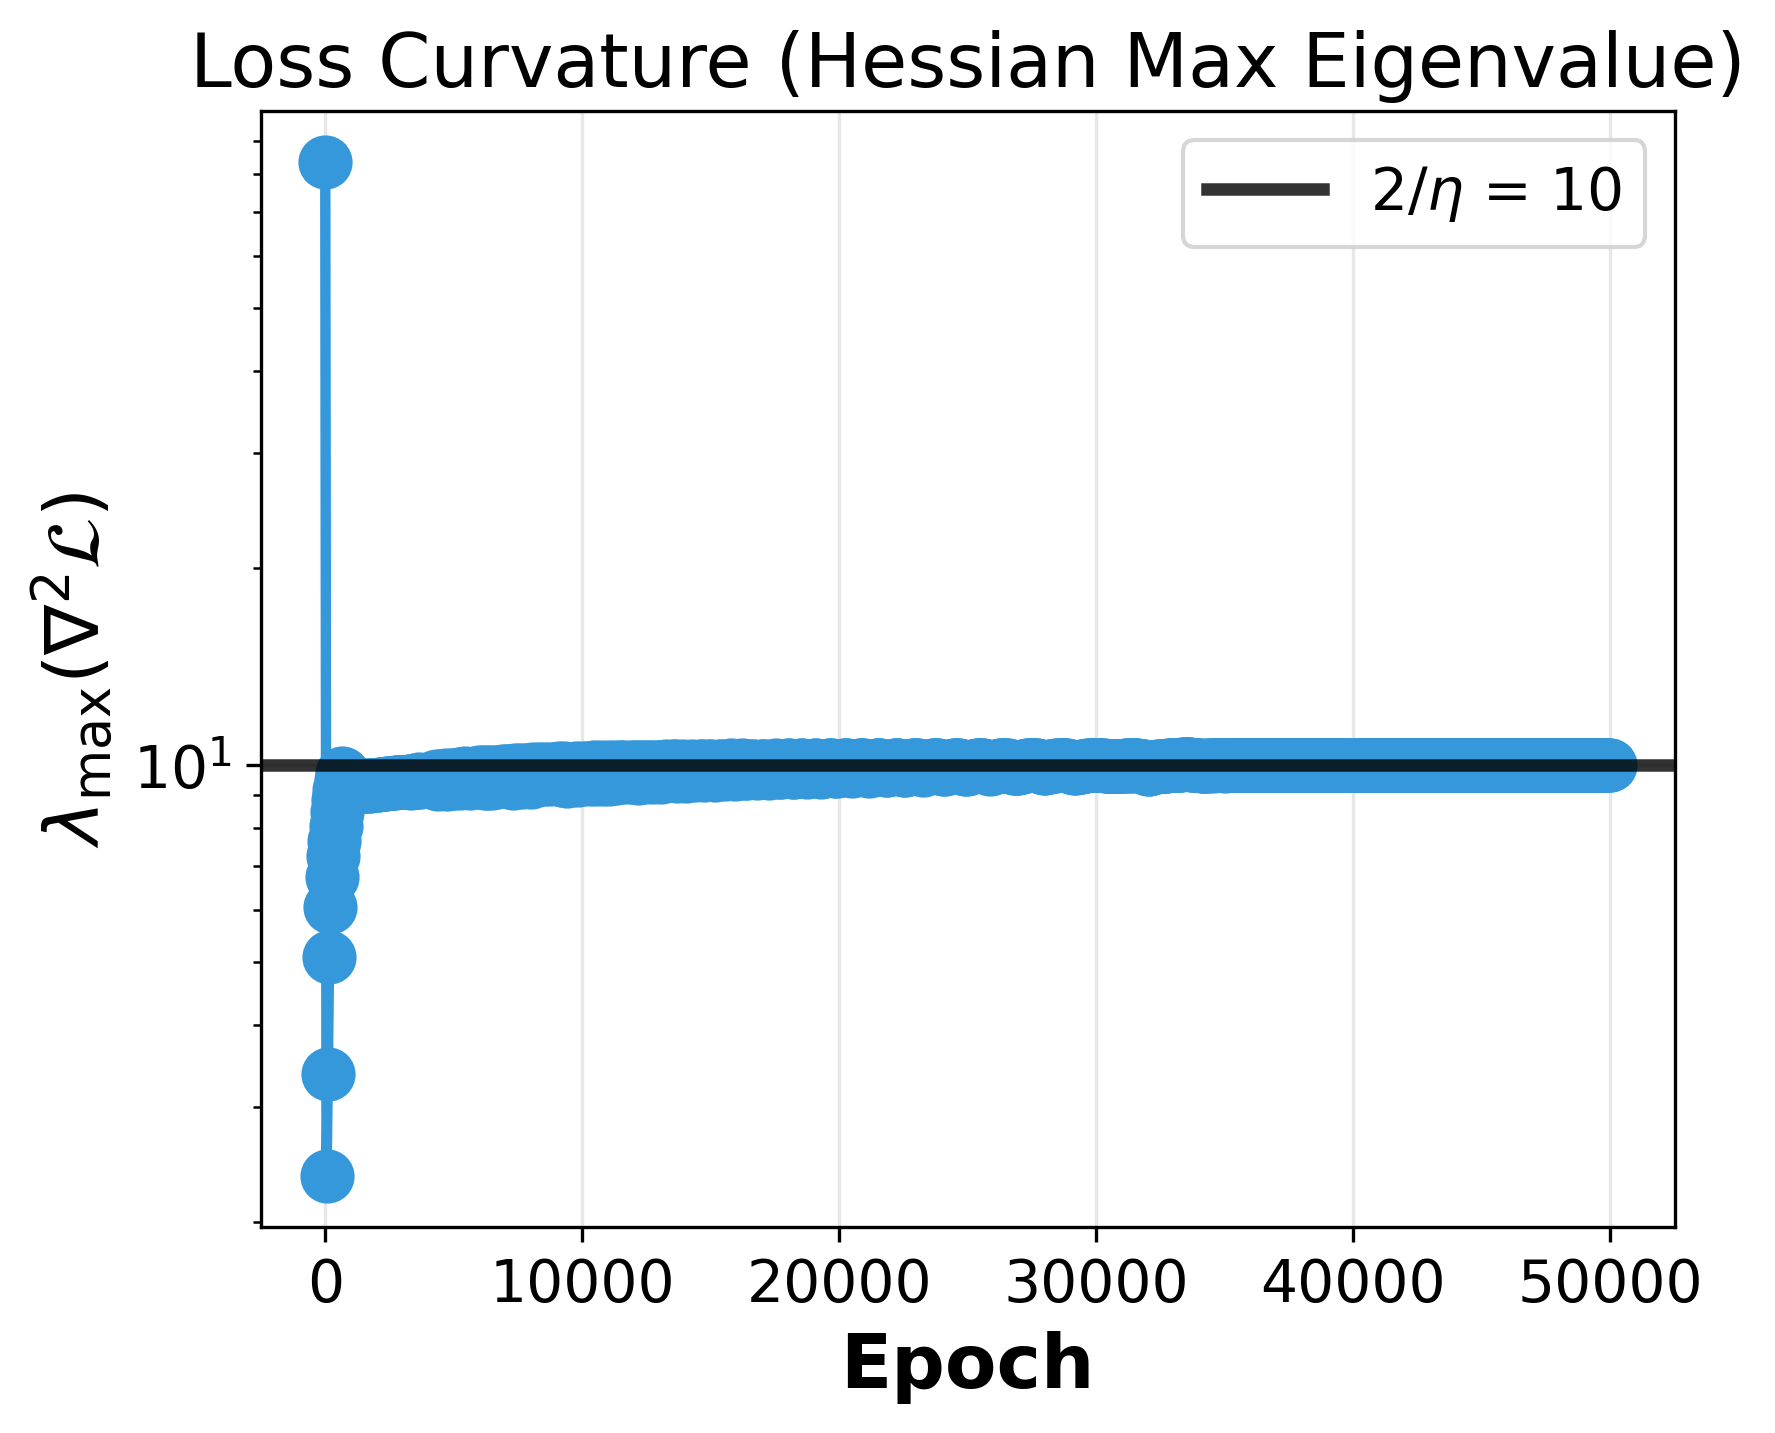

In [10]:
# =============================================================================
# Plot 2: Hessian max eigenvalue over training
# =============================================================================
if len(history['hessian_max_eigenvalue']) > 0:
    fig, ax = plt.subplots(figsize=PLOT_CONFIG['single_fig_size'])
    
    eos = 2.0 / TRAIN_CONFIG['lr']
    
    ax.semilogy(history['hessian_epochs'], history['hessian_max_eigenvalue'], 'o-',
                color=PRETTY_COLORS['LCN-WS'],
                linewidth=PLOT_CONFIG['linewidth'], markersize=PLOT_CONFIG['markersize'])
    ax.axhline(eos, color='black', ls='-', linewidth=3, alpha=0.8, label=f'$2/\\eta$ = {eos:.0f}')
    
    ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
    ax.set_ylabel(r'$\lambda_{\max}(\nabla^2 \mathcal{L})$', fontsize=LABEL_SIZE, fontweight='bold')
    ax.set_title('Loss Curvature (Hessian Max Eigenvalue)', fontsize=TITLE_SIZE)
    ax.legend(loc='best', fontsize=14)
    ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
    ax.tick_params(labelsize=TICK_SIZE)
    
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/exp2_hessian_eigenvalue.pdf', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
    plt.show()
else:
    print("No Hessian data to plot.")

## 7. Plot: Weight Norm vs Activation Rate (Reference Style)

Matching the reference plot style:
- Y-axis: Weight Norm $\|w_k\|$ (log scale)
- X-axis: Activation Rate (percentage)
- Blue: Initial neurons
- Red/Orange: Final neurons

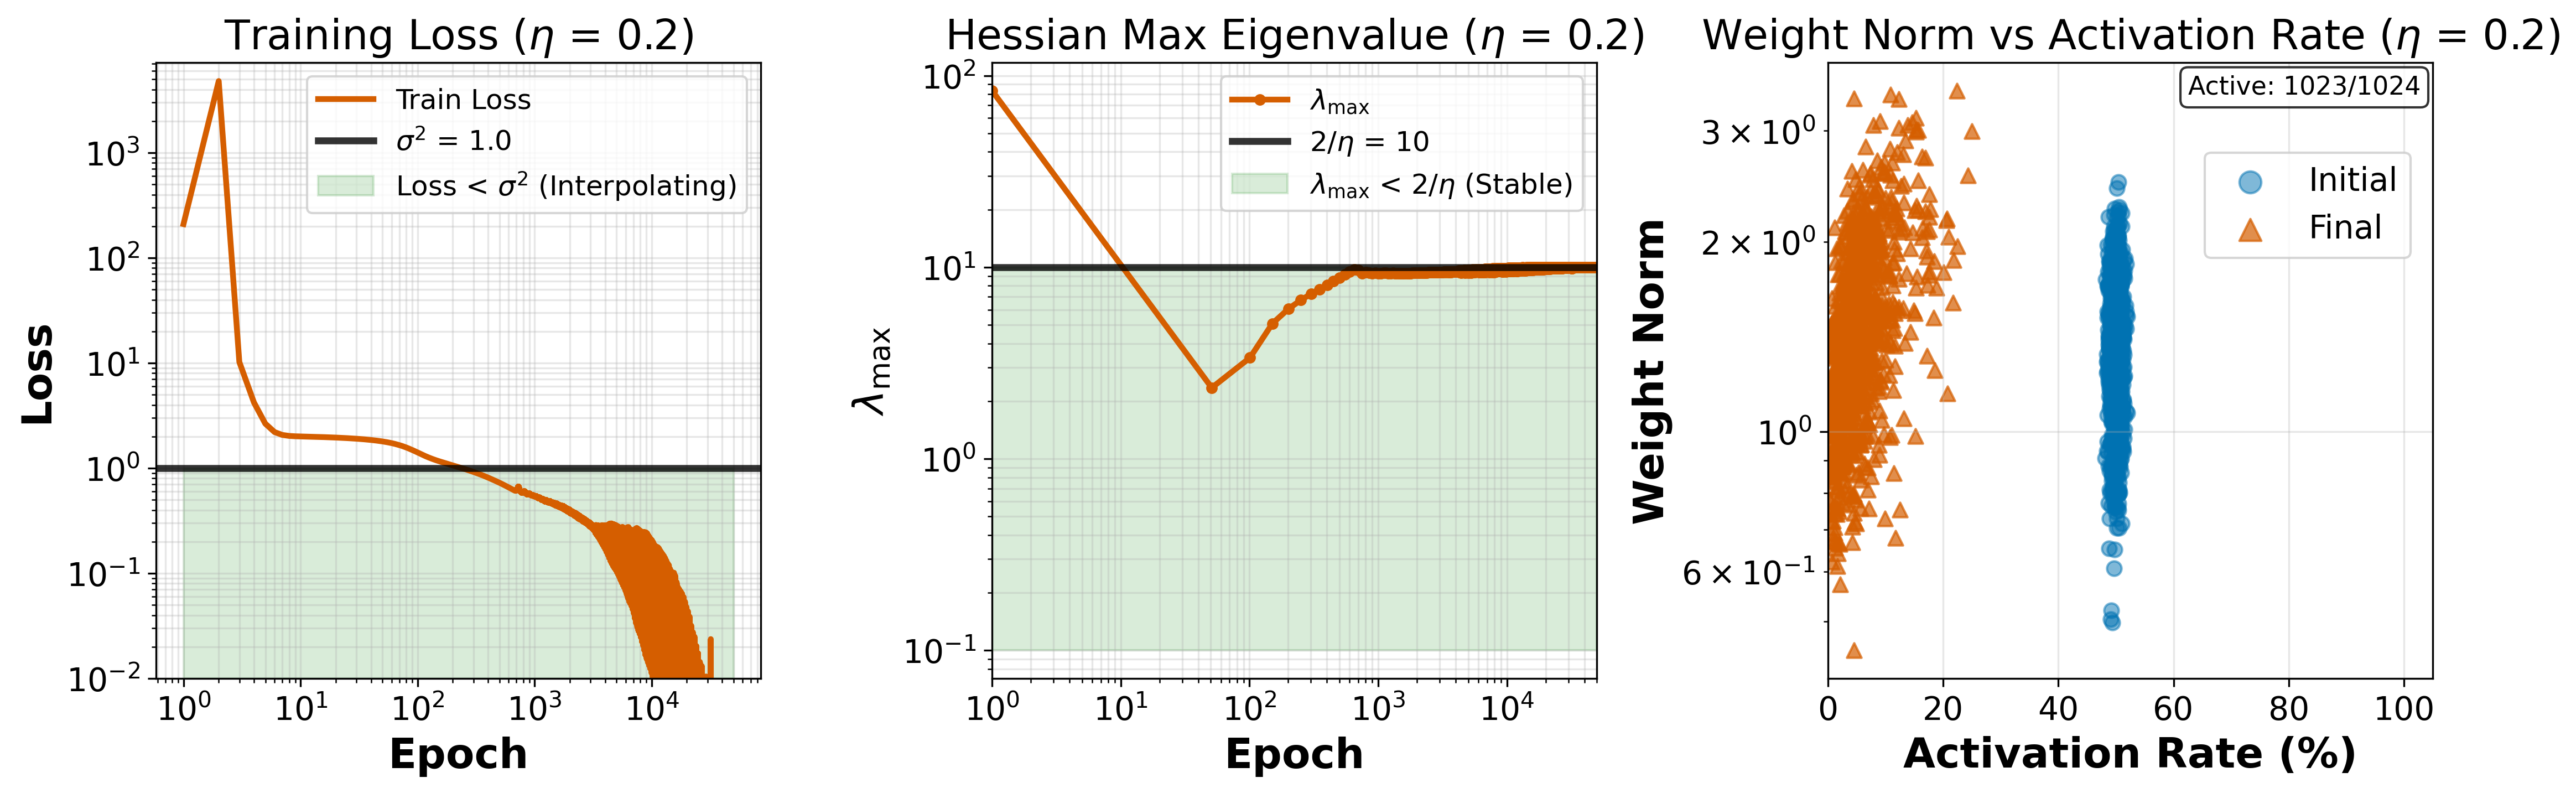


MAIN EXPERIMENT SUMMARY (η = 0.2)
  Final Loss:     0.0000 < σ² ✓ INTERPOLATING
  Final λ_max:    9.99 ≈ 2/η ✓ BEoS SATISFIED
  Active neurons: 1023/1024 (100%)


In [11]:
# =============================================================================
# Plot: Main Experiment - Comprehensive View
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sigma_sq = DATA_CONFIG['sigma'] ** 2
eos = 2.0 / TRAIN_CONFIG['lr']

# -----------------------------------------------------------------------------
# Plot 1: Training Loss (log-log)
# -----------------------------------------------------------------------------
ax = axes[0]
epochs_arr = np.array(range(1, len(history['train_loss']) + 1))

ax.loglog(epochs_arr, history['train_loss'], color='#D55E00', linewidth=PLOT_CONFIG['linewidth'], label='Train Loss')
ax.axhline(sigma_sq, color='black', ls='-', linewidth=3, alpha=0.8, label=f'$\\sigma^2$ = {sigma_sq}')

# Shade interpolation region (in legend)
ax.fill_between(epochs_arr, 0.01, sigma_sq, alpha=0.15, color='green', label=f'Loss < $\\sigma^2$ (Interpolating)')

ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Loss', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Training Loss ($\\eta$ = {TRAIN_CONFIG["lr"]})', fontsize=TITLE_SIZE)
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'], which='both')
ax.set_ylim(0.01, max(history['train_loss']) * 1.5)
ax.tick_params(labelsize=TICK_SIZE)

# -----------------------------------------------------------------------------
# Plot 2: Hessian λ_max with BEoS line (log-log)
# -----------------------------------------------------------------------------
ax = axes[1]

hessian_epochs_arr = np.array(history['hessian_epochs']) + 1
ax.loglog(hessian_epochs_arr, history['hessian_max_eigenvalue'], 
          'o-', color='#D55E00', linewidth=PLOT_CONFIG['linewidth'], markersize=4, label='$\\lambda_{\\max}$')
ax.axhline(eos, color='black', ls='-', linewidth=3, alpha=0.8, label=f'$2/\\eta$ = {eos:.0f}')

# Shade BEoS region (in legend)
ax.fill_between([1, TRAIN_CONFIG['epochs']], 0.1, eos, alpha=0.15, color='green', 
                label=f'$\\lambda_{{\\max}}$ < $2/\\eta$ (Stable)')

ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('$\\lambda_{\\max}$', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Hessian Max Eigenvalue ($\\eta$ = {TRAIN_CONFIG["lr"]})', fontsize=TITLE_SIZE)
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'], which='both')
ax.set_xlim(1, TRAIN_CONFIG['epochs'])
ax.tick_params(labelsize=TICK_SIZE)

# -----------------------------------------------------------------------------
# Plot 3: Weight Norm vs Activation Rate (Point Cloud)
# -----------------------------------------------------------------------------
ax = axes[2]

initial_weight_norms = history['initial_weight_norms']
initial_act_ratios = history['initial_act_ratios']
final_weight_norms = history['weight_norms'][-1]
final_act_ratios = history['activation_ratios'][-1]

active_neurons = np.sum(final_act_ratios > 0)
total_neurons = len(final_act_ratios)

ax.scatter(initial_act_ratios * 100, initial_weight_norms, 
           c='#0072B2', marker='o', alpha=0.5, s=40, label='Initial')
ax.scatter(final_act_ratios * 100, final_weight_norms, 
           c='#D55E00', marker='^', alpha=0.7, s=40, label='Final')

ax.set_yscale('log')
ax.set_xlabel('Activation Rate (%)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Weight Norm', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Weight Norm vs Activation Rate ($\\eta$ = {TRAIN_CONFIG["lr"]})', fontsize=TITLE_SIZE)
ax.set_xlim(0, 105)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
ax.tick_params(labelsize=TICK_SIZE)

ax.text(0.98, 0.98, f'Active: {active_neurons}/{total_neurons}', 
        transform=ax.transAxes, fontsize=11,
        va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.legend(loc='upper right', markerscale=1.5, fontsize=14, bbox_to_anchor=(0.99, 0.88))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/exp2_main_comprehensive.pdf', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
plt.show()

# Print summary (with tolerance for BEoS check)
final_loss = history['train_loss'][-1]
final_lambda = history['hessian_max_eigenvalue'][-1]
beos_tol = 1.02  # 2% tolerance for edge of stability check
print(f"\n{'='*60}")
print(f"MAIN EXPERIMENT SUMMARY (η = {TRAIN_CONFIG['lr']})")
print(f"{'='*60}")
print(f"  Final Loss:     {final_loss:.4f} {'< σ² ✓ INTERPOLATING' if final_loss < sigma_sq else '> σ² ✗'}")
print(f"  Final λ_max:    {final_lambda:.2f} {'≈ 2/η ✓ BEoS SATISFIED' if final_lambda < eos * beos_tol else '> 2/η ✗'}")
print(f"  Active neurons: {active_neurons}/{total_neurons} ({100*active_neurons/total_neurons:.0f}%)")
print(f"{'='*60}")

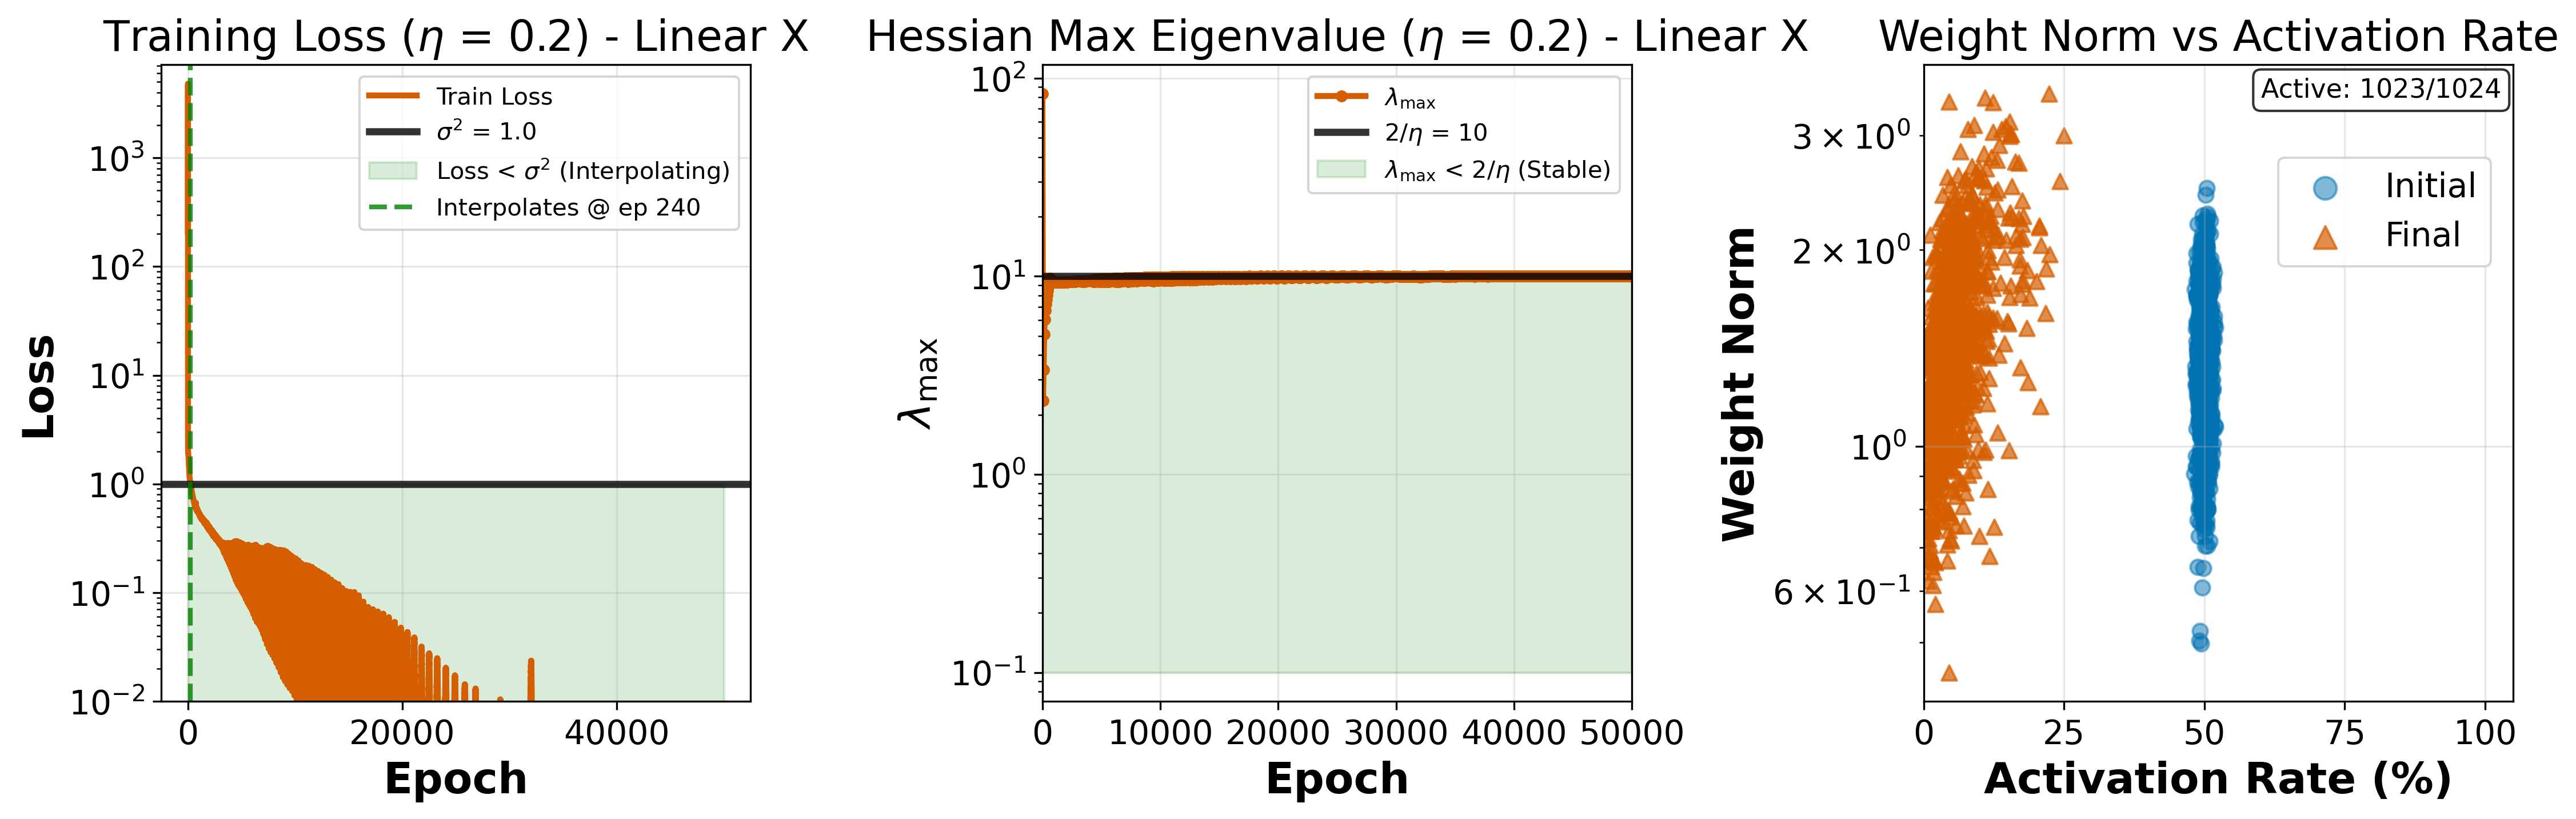


INTERPOLATION TIMING
  Loss drops below σ²=1.0 at epoch 240
  That's 0.5% of total training


In [12]:
# =============================================================================
# Plot: Main Experiment - LINEAR X-AXIS (to show fast interpolation)
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sigma_sq = DATA_CONFIG['sigma'] ** 2
eos = 2.0 / TRAIN_CONFIG['lr']

# -----------------------------------------------------------------------------
# Plot 1: Training Loss (SEMILOGY - linear x, log y)
# -----------------------------------------------------------------------------
ax = axes[0]
epochs_arr = np.array(range(1, len(history['train_loss']) + 1))

ax.semilogy(epochs_arr, history['train_loss'], color='#D55E00', linewidth=PLOT_CONFIG['linewidth'], label='Train Loss')
ax.axhline(sigma_sq, color='black', ls='-', linewidth=3, alpha=0.8, label=f'$\\sigma^2$ = {sigma_sq}')

# Shade interpolation region (in legend)
ax.fill_between(epochs_arr, 0.01, sigma_sq, alpha=0.15, color='green', label=f'Loss < $\\sigma^2$ (Interpolating)')

# Find epoch where loss first drops below σ²
interp_epoch = np.argmax(np.array(history['train_loss']) < sigma_sq) + 1
ax.axvline(interp_epoch, color='green', ls='--', linewidth=2, alpha=0.8, 
           label=f'Interpolates @ ep {interp_epoch}')

ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Loss', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Training Loss ($\\eta$ = {TRAIN_CONFIG["lr"]}) - Linear X', fontsize=TITLE_SIZE)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
ax.set_ylim(0.01, max(history['train_loss']) * 1.5)
ax.tick_params(labelsize=TICK_SIZE)

# -----------------------------------------------------------------------------
# Plot 2: Hessian λ_max (SEMILOGY - linear x, log y)
# -----------------------------------------------------------------------------
ax = axes[1]

ax.semilogy(history['hessian_epochs'], history['hessian_max_eigenvalue'], 
            'o-', color='#D55E00', linewidth=PLOT_CONFIG['linewidth'], markersize=4, label='$\\lambda_{\\max}$')
ax.axhline(eos, color='black', ls='-', linewidth=3, alpha=0.8, label=f'$2/\\eta$ = {eos:.0f}')

# Shade BEoS region (in legend)
ax.fill_between([0, TRAIN_CONFIG['epochs']], 0.1, eos, alpha=0.15, color='green', 
                label=f'$\\lambda_{{\\max}}$ < $2/\\eta$ (Stable)')

ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('$\\lambda_{\\max}$', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Hessian Max Eigenvalue ($\\eta$ = {TRAIN_CONFIG["lr"]}) - Linear X', fontsize=TITLE_SIZE)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
ax.set_xlim(0, TRAIN_CONFIG['epochs'])
ax.tick_params(labelsize=TICK_SIZE)

# -----------------------------------------------------------------------------
# Plot 3: Weight Norm vs Activation Rate (Point Cloud)
# -----------------------------------------------------------------------------
ax = axes[2]

initial_weight_norms = history['initial_weight_norms']
initial_act_ratios = history['initial_act_ratios']
final_weight_norms = history['weight_norms'][-1]
final_act_ratios = history['activation_ratios'][-1]

active_neurons = np.sum(final_act_ratios > 0)
total_neurons = len(final_act_ratios)

ax.scatter(initial_act_ratios * 100, initial_weight_norms, 
           c='#0072B2', marker='o', alpha=0.5, s=40, label='Initial')
ax.scatter(final_act_ratios * 100, final_weight_norms, 
           c='#D55E00', marker='^', alpha=0.7, s=40, label='Final')

ax.set_yscale('log')
ax.set_xlabel('Activation Rate (%)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Weight Norm', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('Weight Norm vs Activation Rate', fontsize=TITLE_SIZE)
ax.set_xlim(0, 105)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
ax.tick_params(labelsize=TICK_SIZE)

ax.text(0.98, 0.98, f'Active: {active_neurons}/{total_neurons}', 
        transform=ax.transAxes, fontsize=11,
        va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.legend(loc='upper right', markerscale=1.5, fontsize=14, bbox_to_anchor=(0.99, 0.88))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/exp2_main_comprehensive_linear_x.pdf', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
plt.show()

# Print when interpolation starts
print(f"\n{'='*60}")
print(f"INTERPOLATION TIMING")
print(f"{'='*60}")
print(f"  Loss drops below σ²={sigma_sq} at epoch {interp_epoch}")
print(f"  That's {100*interp_epoch/TRAIN_CONFIG['epochs']:.1f}% of total training")
print(f"{'='*60}")

<cell_type>markdown</cell_type>## 7b. Comparison: Effect of Learning Rate on Interpolation

Compare different learning rates with **all other settings identical** to the main experiment:
- weight_decay = 0, momentum = 0, grad_clip = same as main
- Kaiming He initialization, zero biases

**Key question**: How does learning rate affect:
1. Whether the model reaches edge of stability (λ_max → 2/η)?
2. Whether the model interpolates (loss < σ²)?
3. Neuron specialization patterns?

**Learning rates tested:**
- **High LR (η=0.9)**: Edge of stability = 4.0 — very aggressive
- **Low LR (η=0.01)**: Edge of stability = 200.0 — very conservative

In [13]:
# =============================================================================
# Run experiments with different learning rates for comparison
# All settings same as main experiment, only LR varies
# =============================================================================

def run_experiment_for_comparison(lr, grad_clip, epochs=10000, log_every=1000, 
                                   hessian_frequency=500):
    """Run experiment with specified learning rate, tracking all metrics.

    Uses same settings as main experiment:
    - weight_decay=0, momentum=0
    - Kaiming He weights + zero biases
    - Hessian tracking enabled

    Args:
        lr: Learning rate
        grad_clip: Gradient clipping threshold
        epochs: Number of training epochs
        log_every: Logging frequency
        hessian_frequency: How often to compute Hessian eigenvalue

    Returns:
        Dictionary with full training history
    """

    # Create fresh model (uses Kaiming He weights + zero biases by default)
    model = create_model('shared_cnn', DATA_CONFIG['d'], DATA_CONFIG['m'],
                         DATA_CONFIG['K_model'], H, DATA_CONFIG['seed'],
                         bias_init=None)
    model = model.to(DEVICE)

    # Capture initial state
    X_dev = X_train.to(DEVICE)
    y_dev = y_noisy_train.to(DEVICE)
    
    init_wn = compute_weight_norms(model)
    init_ar = compute_filter_activation_ratio(model, X_dev, H)
    
    # Create optimizer (same as main: SGD, no momentum, no weight decay)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.0, weight_decay=0.0)
    criterion = nn.MSELoss()

    # History tracking
    history = {
        'train_loss': [],
        'hessian_max_eigenvalue': [],
        'hessian_epochs': [],
    }

    # Training loop
    for ep in tqdm(range(epochs), desc=f"lr={lr}, grad_clip={grad_clip}"):
        model.train()
        opt.zero_grad()
        pred = model(X_dev)
        loss = criterion(pred, y_dev)
        loss.backward()

        # Gradient clipping
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        opt.step()

        # Track loss
        model.eval()
        with torch.no_grad():
            train_loss = criterion(model(X_dev), y_dev).item()
        history['train_loss'].append(train_loss)

        # Hessian computation (at specified frequency)
        if ep % hessian_frequency == 0 or ep == epochs - 1:
            if PYHESSIAN_AVAILABLE:
                lambda_max = compute_hessian_max_eigenvalue_pyhessian(model, X_dev, y_dev, criterion)
            else:
                lambda_max = compute_hessian_max_eigenvalue_power_iter(model, X_dev, y_dev, criterion, 20)
            history['hessian_max_eigenvalue'].append(lambda_max)
            history['hessian_epochs'].append(ep)

        if ep % log_every == 0:
            lambda_str = f", λ_max={history['hessian_max_eigenvalue'][-1]:.2f}" if ep in history['hessian_epochs'] else ""
            tqdm.write(f"  Ep {ep}: loss={train_loss:.4f}{lambda_str}")

    # Final state
    model.eval()
    final_wn = compute_weight_norms(model)
    final_ar = compute_filter_activation_ratio(model, X_dev, H)
    final_loss = criterion(model(X_dev), y_dev).item()

    # Compute final Hessian if not already done
    if epochs - 1 not in history['hessian_epochs']:
        if PYHESSIAN_AVAILABLE:
            lambda_max = compute_hessian_max_eigenvalue_pyhessian(model, X_dev, y_dev, criterion)
        else:
            lambda_max = compute_hessian_max_eigenvalue_power_iter(model, X_dev, y_dev, criterion, 20)
        history['hessian_max_eigenvalue'].append(lambda_max)
        history['hessian_epochs'].append(epochs - 1)

    return {
        'init_wn': init_wn,
        'init_ar': init_ar,
        'final_wn': final_wn,
        'final_ar': final_ar,
        'final_loss': final_loss,
        'lr': lr,
        'grad_clip': grad_clip,
        'edge_of_stability': 2.0 / lr,
        'final_lambda_max': history['hessian_max_eigenvalue'][-1],
        'history': history,
    }

# =============================================================================
# Run comparison experiments with different learning rates
# =============================================================================
print("="*60)
print("COMPARISON: Varying Learning Rate Only")
print("="*60)

print("\n" + "-"*60)
print("Experiment 1: High LR (η=0.4), Edge of stability = 5.0")
print("-"*60)
results_high_lr = run_experiment_for_comparison(
    lr=0.5, 
    grad_clip=50,  # <-- Change this if needed for high LR
    epochs=20000
)

print("\n" + "-"*60)
print("Experiment 2: Low LR (η=0.01), Edge of stability = 200.0")
print("-"*60)
results_low_lr = run_experiment_for_comparison(
    lr=0.05, 
    grad_clip=50,  # <-- Change this if needed for low LR
    epochs=10000
)

print("\n" + "="*60)
print("Both experiments complete!")
print("="*60)

COMPARISON: Varying Learning Rate Only

------------------------------------------------------------
Experiment 1: High LR (η=0.4), Edge of stability = 5.0
------------------------------------------------------------


lr=0.5, grad_clip=50:   0%|          | 61/20000 [00:00<00:32, 607.37it/s]

  Ep 0: loss=1421.9185, λ_max=129.58


lr=0.5, grad_clip=50:   5%|▌         | 1098/20000 [00:01<00:26, 719.84it/s]

  Ep 1000: loss=1.6083, λ_max=3.37


...

  Ep 8000: loss=0.4745, λ_max=40.06


lr=0.05, grad_clip=50:  91%|█████████ | 9124/10000 [00:12<00:01, 697.02it/s]

  Ep 9000: loss=0.4428, λ_max=40.05


lr=0.05, grad_clip=50: 100%|██████████| 10000/10000 [00:14<00:00, 704.14it/s]


Both experiments complete!


Saved: jan27_plots/exp3_comparison_high_lr.pdf


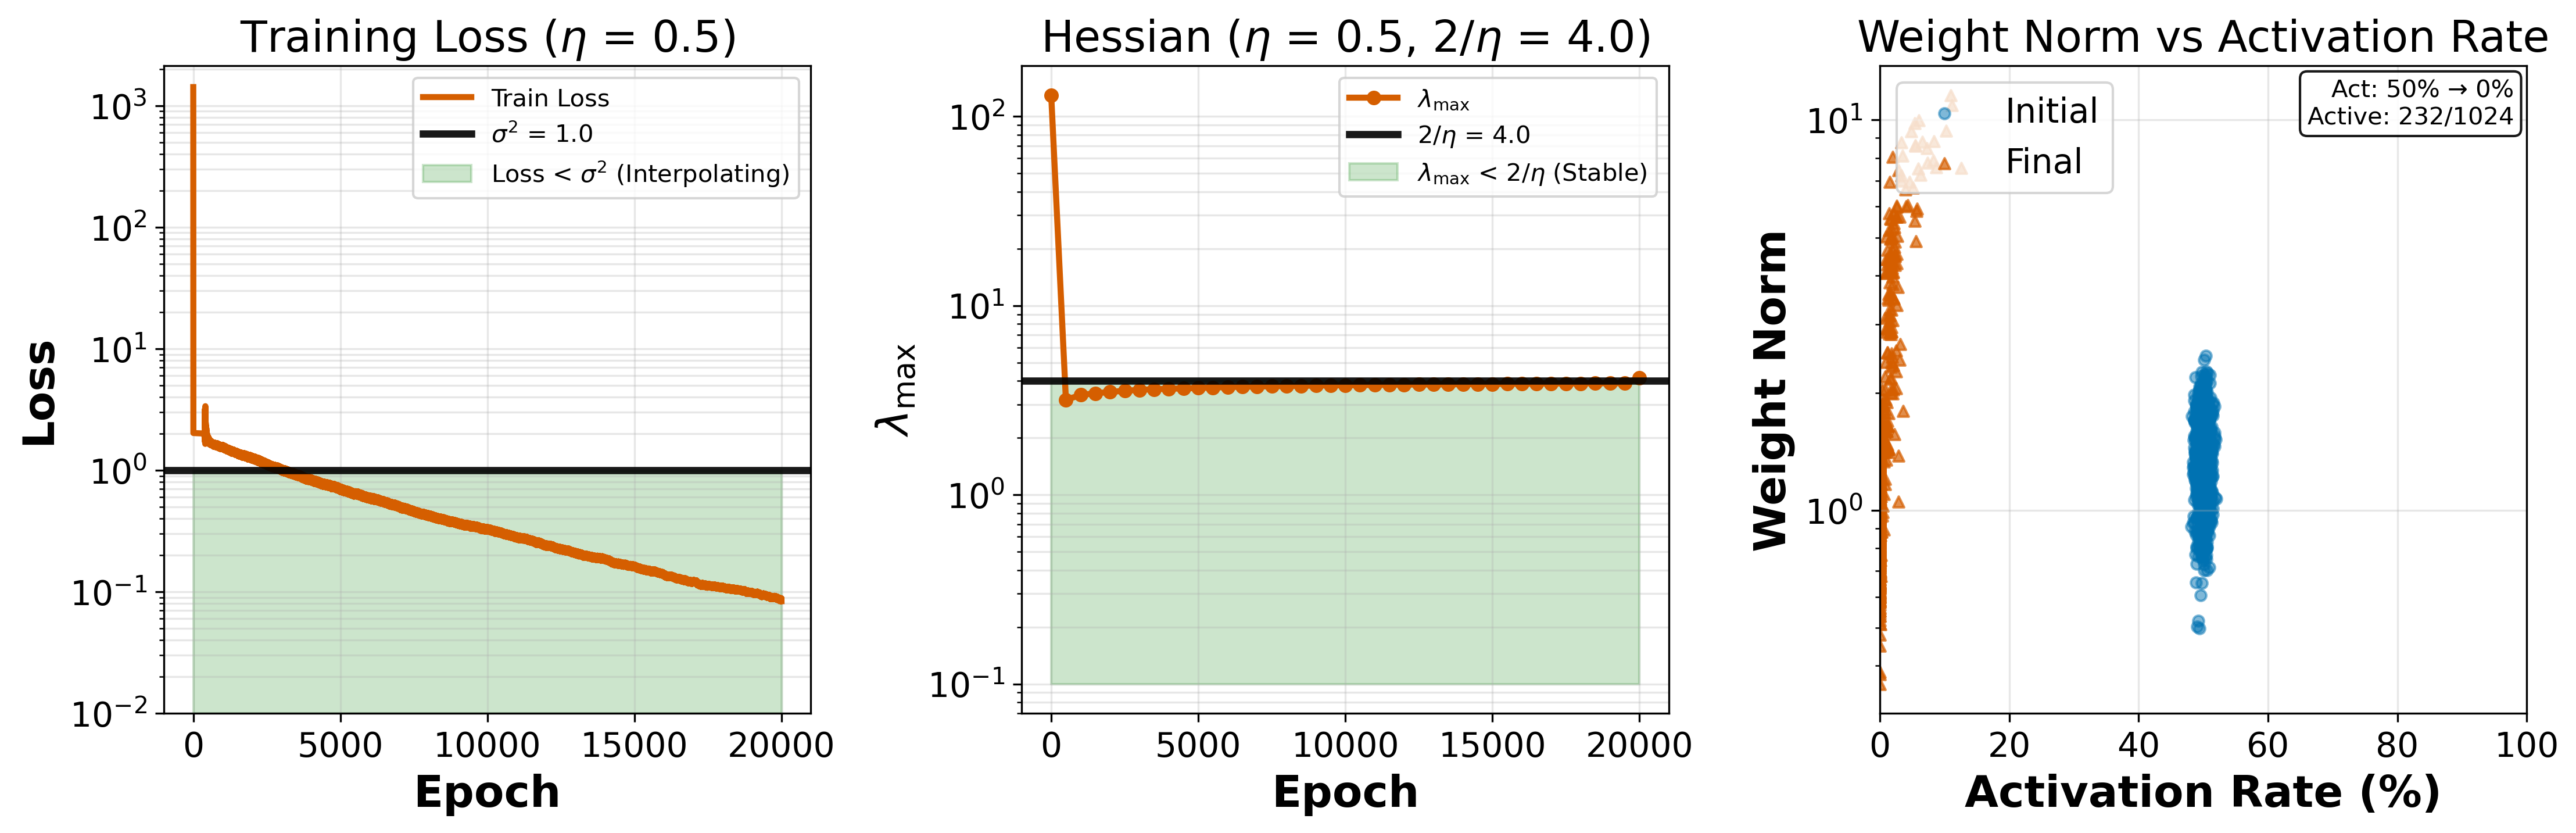

Saved: jan27_plots/exp3_comparison_low_lr.pdf


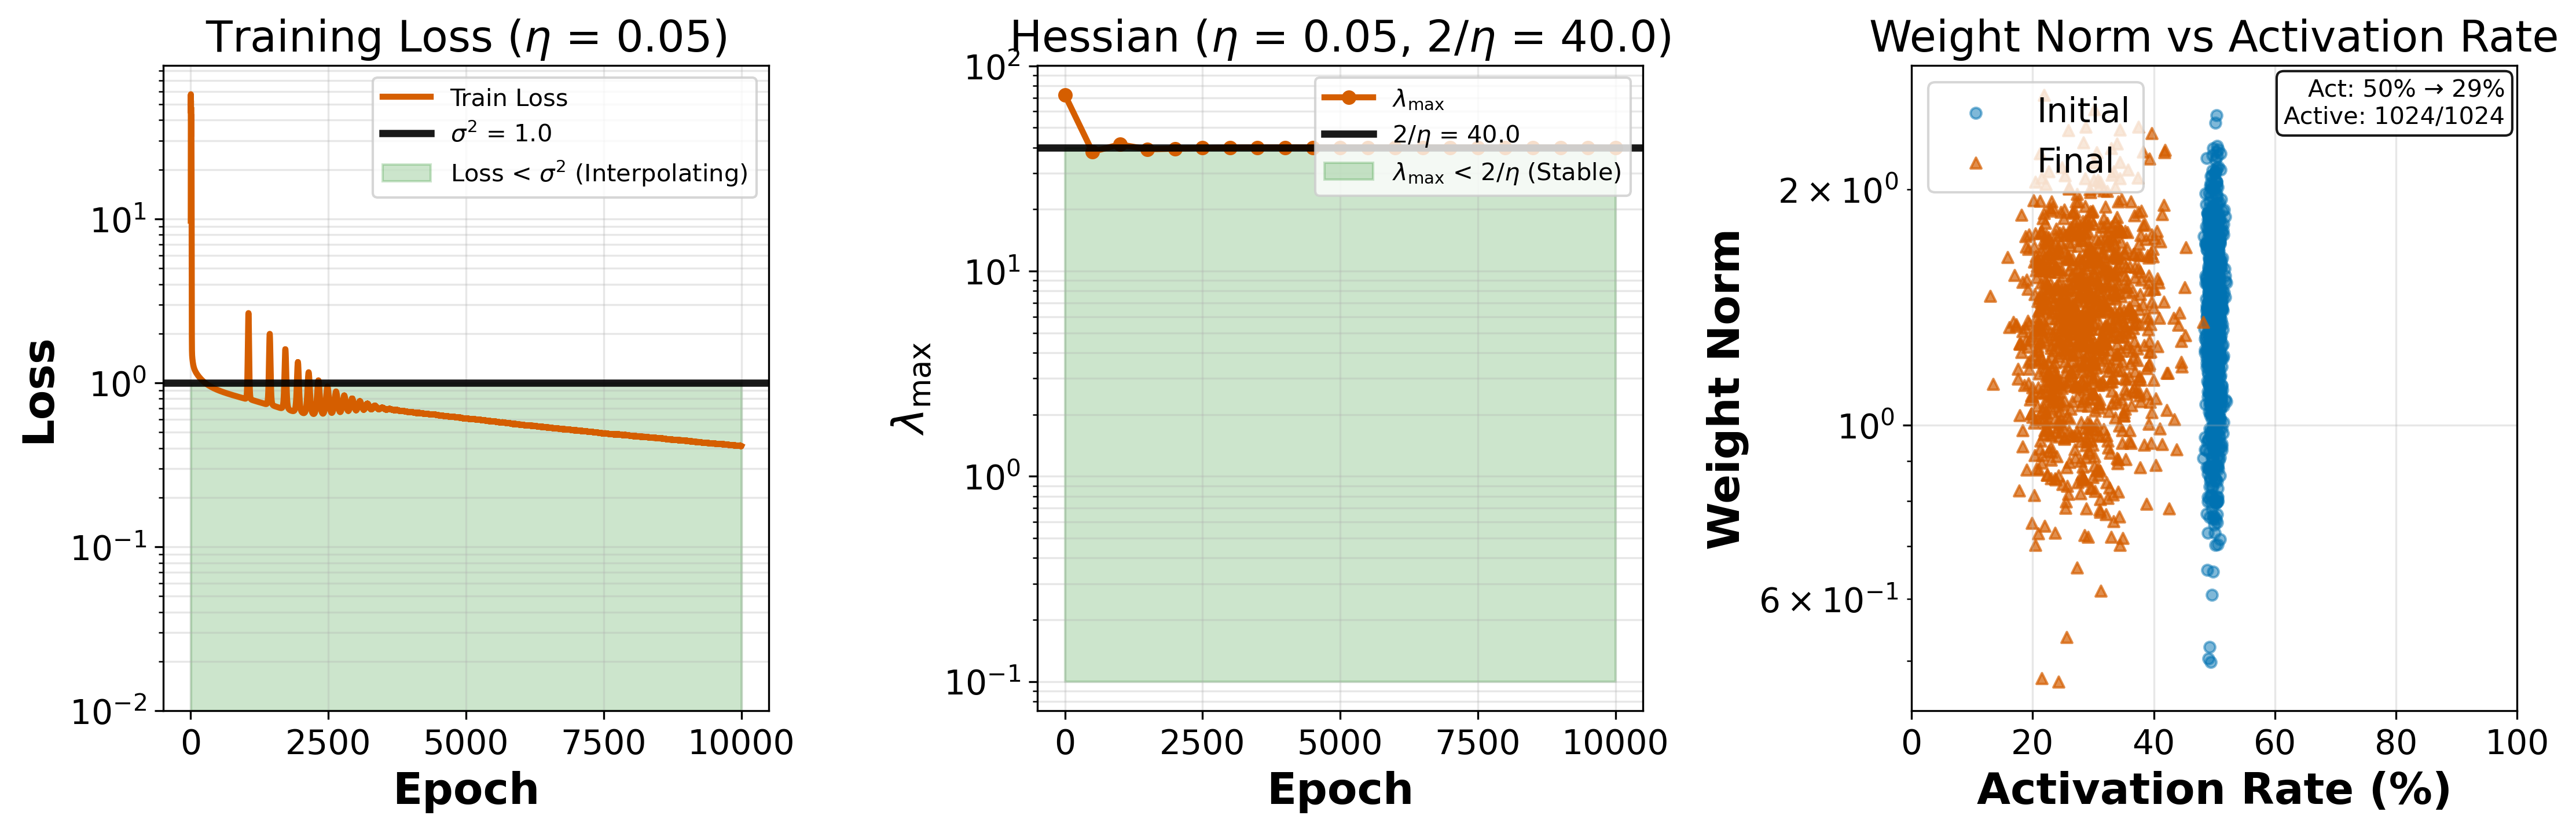


COMPARISON SUMMARY: Effect of Learning Rate
Experiment               LR      2/η     Loss    λ_max    Interp?      BEoS?
--------------------------------------------------------------------------------
Main                   0.20     10.0    0.000     10.0      YES ✓      YES ✓
High LR                0.50      4.0    0.084      4.1      YES ✓       NO ✗
Low LR                 0.05     40.0    0.412     39.9      YES ✓      YES ✓
σ² = 1.0 (interpolation threshold)


In [14]:
# =============================================================================
# Plot: Comparison of different learning rates (Improved Visibility)
# Save each row as separate PDF
# =============================================================================

sigma_sq = DATA_CONFIG['sigma'] ** 2

for idx, (results, name) in enumerate([(results_high_lr, "High LR"), (results_low_lr, "Low LR")]):
    # Create separate figure for each learning rate
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    lr = results['lr']
    eos = results['edge_of_stability']
    
    # -------------------------------------------------------------------------
    # Column 1: Training Loss (log scale)
    # -------------------------------------------------------------------------
    ax = axes[0]
    
    epochs_arr = np.array(range(1, len(results['history']['train_loss']) + 1))
    ax.semilogy(epochs_arr, results['history']['train_loss'], color='#D55E00', 
                linewidth=PLOT_CONFIG['linewidth'], label='Train Loss')
    
    # σ² line - THICK BLACK
    ax.axhline(sigma_sq, color='black', ls='-', linewidth=3, alpha=0.9, label=f'$\\sigma^2$ = {sigma_sq}')
    
    # Shade interpolation region (add to legend)
    ax.fill_between(epochs_arr, 0.01, sigma_sq, alpha=0.2, color='green', label=f'Loss < $\\sigma^2$ (Interpolating)')
    
    ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=LABEL_SIZE, fontweight='bold')
    ax.set_title(f'Training Loss ($\\eta$ = {lr})', fontsize=TITLE_SIZE)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'], which='both')
    ax.set_ylim(0.01, max(results['history']['train_loss']) * 1.5)
    ax.tick_params(labelsize=TICK_SIZE)
    
    # -------------------------------------------------------------------------
    # Column 2: Hessian λ_max
    # -------------------------------------------------------------------------
    ax = axes[1]
    
    ax.semilogy(results['history']['hessian_epochs'], results['history']['hessian_max_eigenvalue'], 
                'o-', color='#D55E00', linewidth=PLOT_CONFIG['linewidth'], markersize=5, label='$\\lambda_{\\max}$')
    
    # BEoS line - THICK BLACK
    ax.axhline(eos, color='black', ls='-', linewidth=3, alpha=0.9, label=f'$2/\\eta$ = {eos:.1f}')
    
    # Shade BEoS region (add to legend with proper label)
    ax.fill_between([0, len(results['history']['train_loss'])], 0.1, eos, alpha=0.2, color='green', 
                    label=f'$\\lambda_{{\\max}}$ < $2/\\eta$ (Stable)')
    
    ax.set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
    ax.set_ylabel('$\\lambda_{\\max}$', fontsize=LABEL_SIZE, fontweight='bold')
    ax.set_title(f'Hessian ($\\eta$ = {lr}, $2/\\eta$ = {eos:.1f})', fontsize=TITLE_SIZE)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'], which='both')
    ax.tick_params(labelsize=TICK_SIZE)
    
    # -------------------------------------------------------------------------
    # Column 3: Neuron Point Cloud
    # -------------------------------------------------------------------------
    ax = axes[2]
    
    init_ar = results['init_ar'] * 100
    init_wn = results['init_wn']
    final_ar = results['final_ar'] * 100
    final_wn = results['final_wn']
    
    active = np.sum(results['final_ar'] > 0)
    total = len(results['final_ar'])
    
    ax.scatter(init_ar, init_wn, c='#0072B2', marker='o', alpha=0.5, s=20, label='Initial')
    ax.scatter(final_ar, final_wn, c='#D55E00', marker='^', alpha=0.7, s=20, label='Final')
    
    ax.set_yscale('log')
    ax.set_xlabel('Activation Rate (%)', fontsize=LABEL_SIZE, fontweight='bold')
    ax.set_ylabel('Weight Norm', fontsize=LABEL_SIZE, fontweight='bold')
    ax.set_title('Weight Norm vs Activation Rate', fontsize=TITLE_SIZE)
    ax.set_xlim(0, 100)
    ax.legend(loc='upper left', fontsize=14)
    ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
    ax.tick_params(labelsize=TICK_SIZE)
    
    # Stats - keep this one
    info = f'Act: {init_ar.mean():.0f}% → {final_ar.mean():.0f}%\nActive: {active}/{total}'
    ax.text(0.98, 0.98, info, transform=ax.transAxes, fontsize=10,
            va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    plt.tight_layout()
    
    # Save each row as separate PDF
    filename = f'{SAVE_DIR}/exp3_comparison_{name.lower().replace(" ", "_")}.pdf'
    plt.savefig(filename, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
    print(f"Saved: {filename}")
    plt.show()

# Print detailed summary table
print("\n" + "="*80)
print("COMPARISON SUMMARY: Effect of Learning Rate")
print("="*80)
print(f"{'Experiment':<20} {'LR':>6} {'2/η':>8} {'Loss':>8} {'λ_max':>8} {'Interp?':>10} {'BEoS?':>10}")
print("-"*80)

for name, res in [("Main", {'final_loss': history['train_loss'][-1], 
                            'lr': TRAIN_CONFIG['lr'],
                            'final_lambda_max': history['hessian_max_eigenvalue'][-1]}),
                  ("High LR", results_high_lr), 
                  ("Low LR", results_low_lr)]:
    lr = res['lr']
    eos = 2.0 / lr
    loss = res['final_loss']
    lmax = res['final_lambda_max']
    interp = "YES ✓" if loss < sigma_sq else "NO ✗"
    beos = "YES ✓" if lmax < eos * 1.02 else "NO ✗"  # 2% tolerance for edge of stability
    
    print(f"{name:<20} {lr:>6.2f} {eos:>8.1f} {loss:>8.3f} {lmax:>8.1f} {interp:>10} {beos:>10}")

print("="*80)
print(f"σ² = {sigma_sq} (interpolation threshold)")
print("="*80)

## 8. Summary

In [15]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("="*70)
print("EXPERIMENT 2: FLAT INTERPOLATION - SUMMARY")
print("="*70)

# Compute BEoS check
final_lambda = history['hessian_max_eigenvalue'][-1]
edge_of_stability = 2.0 / TRAIN_CONFIG['lr']
beos_satisfied = final_lambda < edge_of_stability

print(f"\nSetup:")
print(f"  Data: Patch-wise sphere sampling")
print(f"    - Each patch x^(j) ~ S^{{m-1}} independently")
print(f"    - m={DATA_CONFIG['m']}, J={DATA_CONFIG['J']}, d={DATA_CONFIG['d']}")
print(f"  Model: LCN-WS with K={DATA_CONFIG['K_model']} filters")
print(f"  Training: lr={TRAIN_CONFIG['lr']}, no gradient clipping")

print(f"\nBEoS Analysis:")
print(f"  Edge of stability (2/η): {edge_of_stability:.1f}")
print(f"  Final λ_max:             {final_lambda:.2f}")
print(f"  BEoS satisfied?          {'YES' if beos_satisfied else 'NO'} (λ_max < 2/η)")

print(f"\nTraining Results:")
print(f"  Train Loss (noisy): {history['train_loss'][-1]:.4f}")
print(f"  Train MSE (clean):  {history['train_mse_clean'][-1]:.4f}")
print(f"  σ² (noise):         {DATA_CONFIG['sigma']**2:.4f}")

if len(history['weight_norms']) > 0:
    wn_init = history['initial_weight_norms']
    wn_final = history['weight_norms'][-1]
    ar_init = history['initial_act_ratios']
    ar_final = history['activation_ratios'][-1]
    active_neurons = np.sum(ar_final > 0)
    
    print(f"\nNeuron Analysis:")
    print(f"  Active neurons: {active_neurons}/{len(ar_final)} ({100*active_neurons/len(ar_final):.1f}%)")
    print(f"  Initial Weight Norm: mean={wn_init.mean():.4f}, max={wn_init.max():.4f}")
    print(f"  Final Weight Norm:   mean={wn_final.mean():.4f}, max={wn_final.max():.4f}")
    print(f"  Initial Act Rate:    mean={ar_init.mean()*100:.1f}%")
    print(f"  Final Act Rate:      mean={ar_final.mean()*100:.1f}%")

print(f"\n" + "="*70)
print("KEY TAKEAWAY:")
print("="*70)
print(f"""
With lr={TRAIN_CONFIG['lr']} and NO gradient clipping:
  - λ_max ≈ {final_lambda:.0f} < {edge_of_stability:.0f} = 2/η  →  BEoS SATISFIED
  - Train loss ≈ {history['train_loss'][-1]:.2f} (close to σ² = {DATA_CONFIG['sigma']**2})
  - MSE clean ≈ {history['train_mse_clean'][-1]:.3f} (learning the true function)

This demonstrates that even with BEoS satisfied (flat minimum),
LCN-WS can interpolate - showing architecture alone doesn't guarantee
generalization without data distribution assumptions.
""")
print("="*70)

EXPERIMENT 2: FLAT INTERPOLATION - SUMMARY

Setup:
  Data: Patch-wise sphere sampling
    - Each patch x^(j) ~ S^{m-1} independently
    - m=10, J=8, d=80
  Model: LCN-WS with K=1024 filters
  Training: lr=0.2, no gradient clipping

BEoS Analysis:
  Edge of stability (2/η): 10.0
  Final λ_max:             9.99
  BEoS satisfied?          YES (λ_max < 2/η)

Training Results:
  Train Loss (noisy): 0.0000
  Train MSE (clean):  1.0418
  σ² (noise):         1.0000

Neuron Analysis:
  Active neurons: 1023/1024 (99.9%)
  Initial Weight Norm: mean=1.3845, max=2.4876
  Final Weight Norm:   mean=1.4832, max=3.4758
  Initial Act Rate:    mean=50.0%
  Final Act Rate:      mean=5.5%

KEY TAKEAWAY:

With lr=0.2 and NO gradient clipping:
  - λ_max ≈ 10 < 10 = 2/η  →  BEoS SATISFIED
  - Train loss ≈ 0.00 (close to σ² = 1.0)
  - MSE clean ≈ 1.042 (learning the true function)

This demonstrates that even with BEoS satisfied (flat minimum),
LCN-WS can interpolate - showing architecture alone doesn't guara

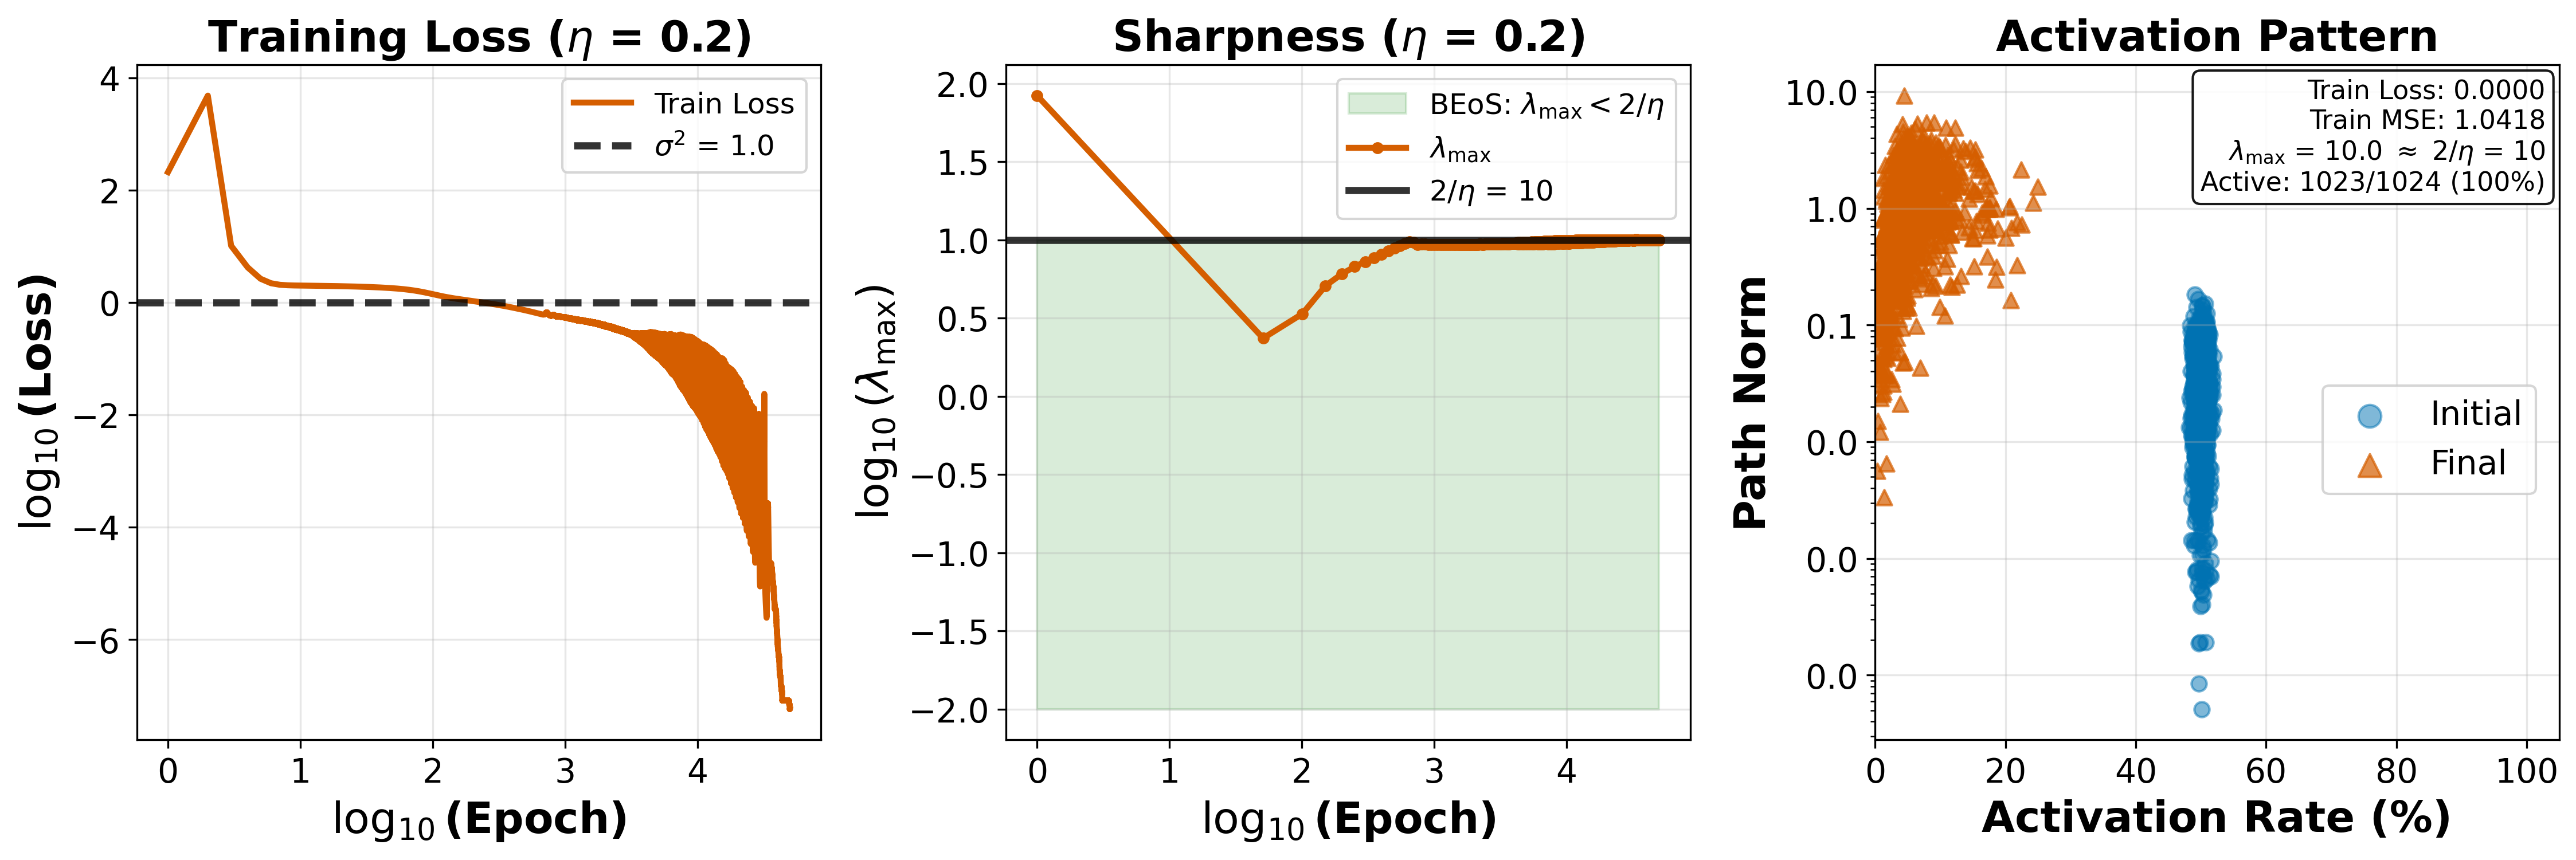

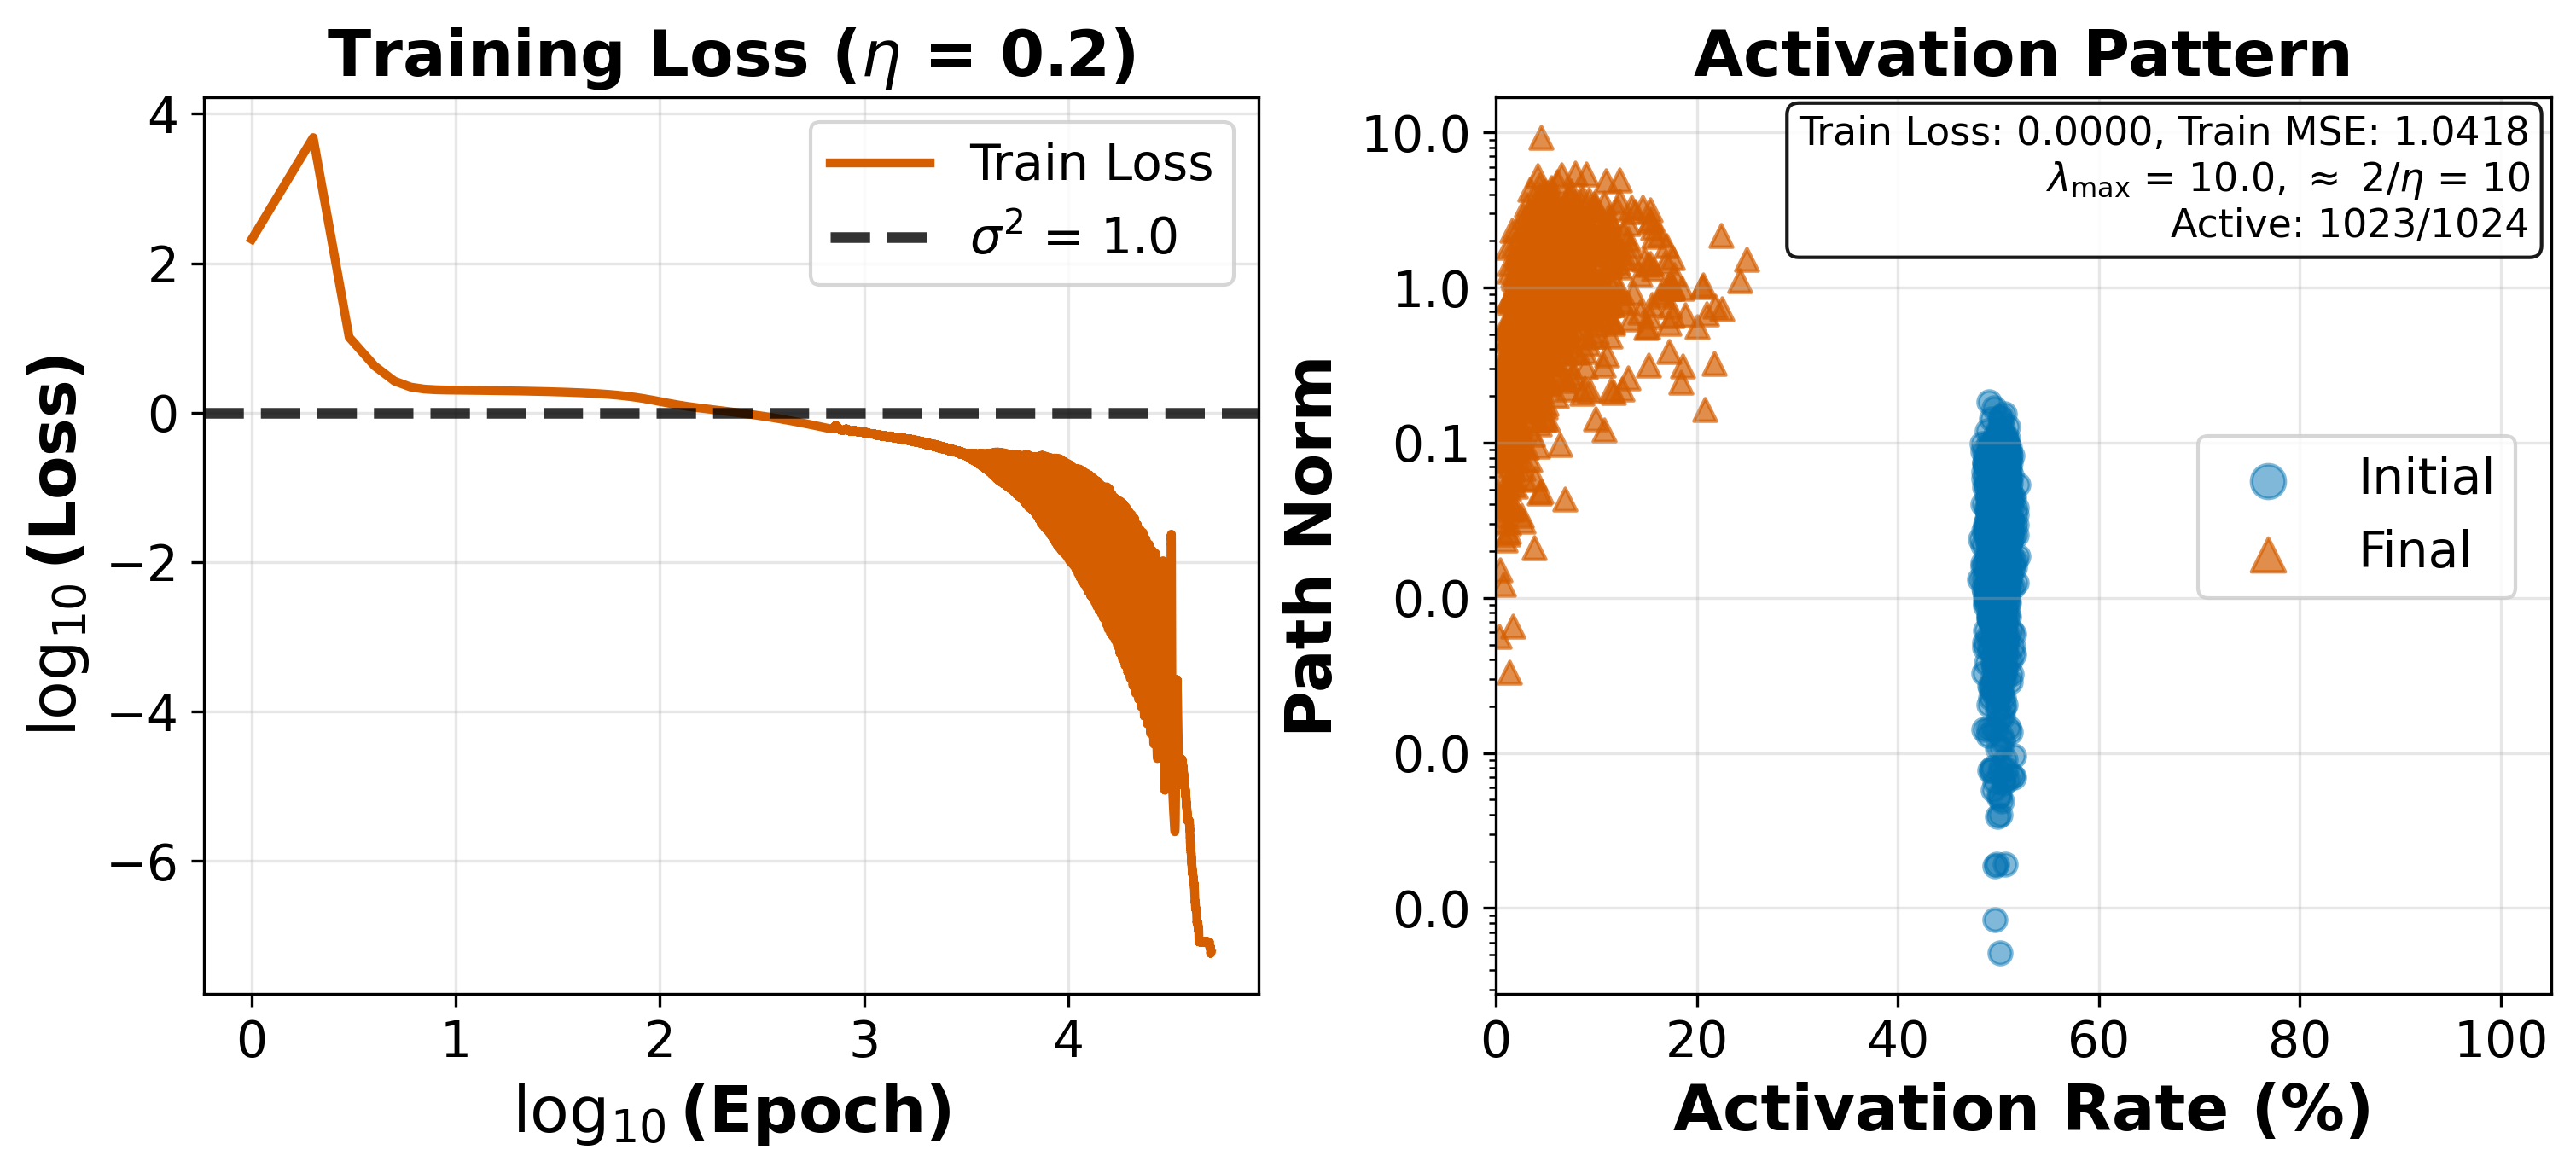

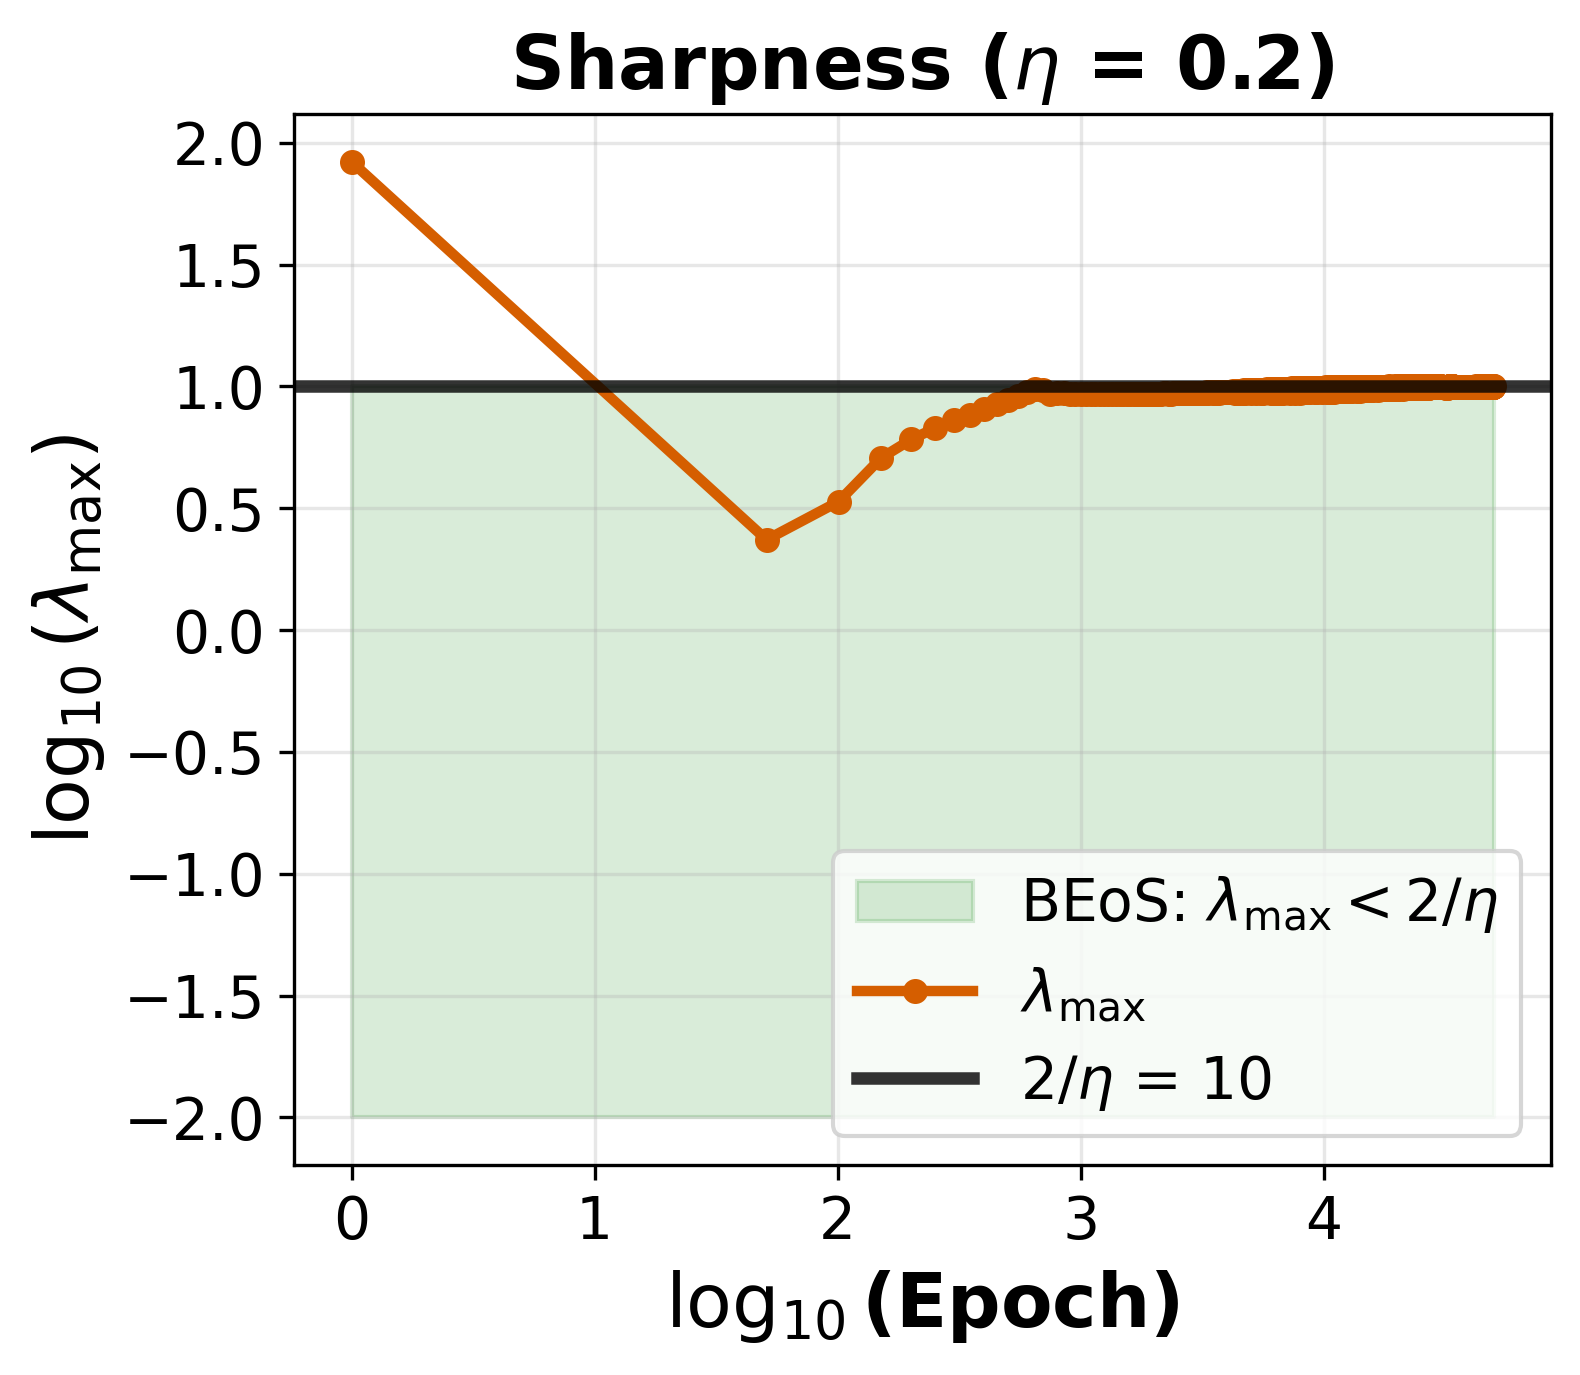


Saved:
  jan27_plots/exp2_loss_and_activation.pdf
  jan27_plots/exp2_sharpness.pdf


In [34]:
# =============================================================================
# Final Summary Figure: Training Loss, Sharpness, and Activation Pattern
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sigma_sq = DATA_CONFIG['sigma'] ** 2
eos = 2.0 / TRAIN_CONFIG['lr']

# -----------------------------------------------------------------------------
# Plot 1: Training Loss (log10 scale for even grid)
# -----------------------------------------------------------------------------
ax = axes[0]
epochs_arr = np.array(range(1, len(history['train_loss']) + 1))

# Plot in log10 space (clip loss to avoid log(0))
log_epochs = np.log10(epochs_arr)
log_loss = np.log10(np.maximum(history['train_loss'], 1e-10))
log_sigma_sq = np.log10(sigma_sq)

ax.plot(log_epochs, log_loss, color='#D55E00', linewidth=PLOT_CONFIG['linewidth'], label='Train Loss')
ax.axhline(log_sigma_sq, color='black', ls='--', linewidth=3, alpha=0.8, label=f'$\\sigma^2$ = {sigma_sq}')

ax.set_xlabel(r'$\log_{10}$(Epoch)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel(r'$\log_{10}$(Loss)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Training Loss ($\\eta$ = {TRAIN_CONFIG["lr"]})', fontsize=TITLE_SIZE, fontweight='bold')
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
ax.tick_params(labelsize=TICK_SIZE)

# -----------------------------------------------------------------------------
# Plot 2: Hessian λ_max with BEoS line (log10 scale for even grid)
# -----------------------------------------------------------------------------
ax = axes[1]

hessian_epochs_arr = np.array(history['hessian_epochs']) + 1
log_hessian_epochs = np.log10(hessian_epochs_arr)
log_lambda = np.log10(history['hessian_max_eigenvalue'])
log_eos = np.log10(eos)

# Green shading for BEoS region (below 2/η)
ax.fill_between([log_epochs.min(), log_epochs.max()], -2, log_eos, 
                alpha=0.15, color='green', label=r'BEoS: $\lambda_{\max} < 2/\eta$')

ax.plot(log_hessian_epochs, log_lambda, 'o-', color='#D55E00', 
        linewidth=PLOT_CONFIG['linewidth'], markersize=4, label='$\\lambda_{\\max}$')
ax.axhline(log_eos, color='black', ls='-', linewidth=3, alpha=0.8, label=f'$2/\\eta$ = {eos:.0f}')

ax.set_xlabel(r'$\log_{10}$(Epoch)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel(r'$\log_{10}(\lambda_{\max})$', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Sharpness ($\\eta$ = {TRAIN_CONFIG["lr"]})', fontsize=TITLE_SIZE, fontweight='bold')
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
ax.tick_params(labelsize=TICK_SIZE)

# -----------------------------------------------------------------------------
# Plot 3: Path Norm vs Activation Rate
# -----------------------------------------------------------------------------
ax = axes[2]

# Use path norms instead of weight norms
initial_pn = history['initial_path_norms']
initial_ar = history['initial_act_ratios']
final_pn = history['path_norms'][-1]
final_ar = history['activation_ratios'][-1]

# Compute active neurons
active_neurons = np.sum(final_ar > 0)
total_neurons = len(final_ar)

ax.scatter(initial_ar * 100, initial_pn, c='#0072B2', marker='o', alpha=0.5, s=40, label='Initial')
ax.scatter(final_ar * 100, final_pn, c='#D55E00', marker='^', alpha=0.7, s=40, label='Final')

ax.set_yscale('log')
ax.set_xlabel('Activation Rate (%)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Path Norm', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('Activation Pattern', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_xlim(0, 105)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
ax.tick_params(labelsize=TICK_SIZE)

# Fix y-ticks for log scale - use nice decimal values
from matplotlib.ticker import LogLocator, ScalarFormatter
ax.yaxis.set_major_locator(LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis='y', style='plain')

# Floating annotation with final metrics - λ_max ≈ 2/η in one line
final_loss = history['train_loss'][-1]
final_mse = history['train_mse_clean'][-1]
final_lambda = history['hessian_max_eigenvalue'][-1]

annotation_text = (f"Train Loss: {final_loss:.4f}\n"
                   f"Train MSE: {final_mse:.4f}\n"
                   r"$\lambda_{\max}$" + f" = {final_lambda:.1f} " + r"$\approx$ $2/\eta$" + f" = {eos:.0f}\n"
                   f"Active: {active_neurons}/{total_neurons} ({100*active_neurons/total_neurons:.0f}%)")
ax.text(0.98, 0.98, annotation_text, transform=ax.transAxes, fontsize=11,
        va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Legend below the annotation box
ax.legend(loc='upper right', fontsize=14, markerscale=1.5, bbox_to_anchor=(0.99, 0.55))

plt.tight_layout(pad=0.5, w_pad=1.0)
plt.savefig(f'{SAVE_DIR}/exp2_summary_figure.pdf', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
plt.show()

# =============================================================================
# SPLIT FIGURES: Training Loss + Activation (together) | Sharpness (separate)
# =============================================================================

sigma_sq = DATA_CONFIG['sigma'] ** 2
eos = 2.0 / TRAIN_CONFIG['lr']

# -----------------------------------------------------------------------------
# Figure 1: Training Loss + Path Norm vs Activation (side by side, tight)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# --- Subplot 1: Training Loss (log10 scale) ---
ax = axes[0]
epochs_arr = np.array(range(1, len(history['train_loss']) + 1))
log_epochs = np.log10(epochs_arr)
log_loss = np.log10(np.maximum(history['train_loss'], 1e-10))
log_sigma_sq = np.log10(sigma_sq)

ax.plot(log_epochs, log_loss, color='#D55E00', linewidth=PLOT_CONFIG['linewidth'], label='Train Loss')
ax.axhline(log_sigma_sq, color='black', ls='--', linewidth=3, alpha=0.8, label=f'$\\sigma^2$ = {sigma_sq}')

ax.set_xlabel(r'$\log_{10}$(Epoch)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel(r'$\log_{10}$(Loss)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Training Loss ($\\eta$ = {TRAIN_CONFIG["lr"]})', fontsize=TITLE_SIZE, fontweight='bold')
ax.legend(loc='upper right', fontsize=14)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
ax.tick_params(labelsize=TICK_SIZE)

# --- Subplot 2: Path Norm vs Activation Rate ---
ax = axes[1]

# Use path norms
initial_pn = history['initial_path_norms']
initial_ar = history['initial_act_ratios']
final_pn = history['path_norms'][-1]
final_ar = history['activation_ratios'][-1]

active_neurons = np.sum(final_ar > 0)
total_neurons = len(final_ar)
final_loss = history['train_loss'][-1]
final_mse = history['train_mse_clean'][-1]
final_lambda = history['hessian_max_eigenvalue'][-1]

ax.scatter(initial_ar * 100, initial_pn, c='#0072B2', marker='o', alpha=0.5, s=40, label='Initial')
ax.scatter(final_ar * 100, final_pn, c='#D55E00', marker='^', alpha=0.7, s=40, label='Final')

ax.set_yscale('log')
ax.set_xlabel('Activation Rate (%)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Path Norm', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title('Activation Pattern', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_xlim(0, 105)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
ax.tick_params(labelsize=TICK_SIZE)

# Fix y-ticks for log scale - use nice decimal values
ax.yaxis.set_major_locator(LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis='y', style='plain')

# Annotation with Train Loss, Train MSE, λ_max ≈ 2/η, and Active neurons
annotation_text = (f"Train Loss: {final_loss:.4f}, Train MSE: {final_mse:.4f}\n"
                   r"$\lambda_{\max}$" + f" = {final_lambda:.1f}, " + r"$\approx$ $2/\eta$" + f" = {eos:.0f}\n"
                   f"Active: {active_neurons}/{total_neurons}")
ax.text(0.98, 0.98, annotation_text, transform=ax.transAxes, fontsize=11,
        va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax.legend(loc='upper right', fontsize=14, markerscale=1.5, bbox_to_anchor=(0.99, 0.65))

plt.tight_layout(pad=0.3, w_pad=0.5)
plt.savefig(f'{SAVE_DIR}/exp2_loss_and_activation.pdf', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# Figure 2: Sharpness (Hessian λ_max) - standalone
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4.5))

hessian_epochs_arr = np.array(history['hessian_epochs']) + 1
log_hessian_epochs = np.log10(hessian_epochs_arr)
log_lambda = np.log10(history['hessian_max_eigenvalue'])
log_eos = np.log10(eos)

# Green shading for BEoS region (below 2/η)
ax.fill_between([log_hessian_epochs.min(), log_hessian_epochs.max()], -2, log_eos, 
                alpha=0.15, color='green', label=r'BEoS: $\lambda_{\max} < 2/\eta$')

ax.plot(log_hessian_epochs, log_lambda, 'o-', color='#D55E00', 
        linewidth=PLOT_CONFIG['linewidth'], markersize=5, label='$\\lambda_{\\max}$')
ax.axhline(log_eos, color='black', ls='-', linewidth=3, alpha=0.8, label=f'$2/\\eta$ = {eos:.0f}')

ax.set_xlabel(r'$\log_{10}$(Epoch)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel(r'$\log_{10}(\lambda_{\max})$', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Sharpness ($\\eta$ = {TRAIN_CONFIG["lr"]})', fontsize=TITLE_SIZE, fontweight='bold')
ax.legend(loc='lower right', fontsize=14)
ax.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
ax.tick_params(labelsize=TICK_SIZE)

plt.tight_layout(pad=0.3)
plt.savefig(f'{SAVE_DIR}/exp2_sharpness.pdf', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
plt.show()

print(f"\nSaved:")
print(f"  {SAVE_DIR}/exp2_loss_and_activation.pdf")
print(f"  {SAVE_DIR}/exp2_sharpness.pdf")